## Codigo principal para el mecanismo de Pivot

In [6]:
import itertools
import numpy as np
import math
from typing import List, Tuple, Dict
from collections import defaultdict
import matplotlib.pyplot as plt
from mpmath import *

# Definición de tipos
Point = Tuple[float, float]
Trajectory = List[Point]

class PivotSampling:
 def __init__(self, epsilon: float = 1, 
 D_candidates: List[int] = [2, 4, 6, 8, 12], R: float = 6371000.0): 
 self.epsilon_total = epsilon
 self.epsilon_dir = 0.75 * epsilon
 self.epsilon_ind = 0.125 * epsilon 
 self.epsilon_rest = 0.125 * epsilon 
 self.D_candidates = D_candidates
 self.R = R

 self.D_opt = self._select_optimal_granularity()
 
 def haversine_distance(self, p1: Point, p2: Point) -> float:
 """Distancia Haversine en metros"""
 lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
 lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
 
 dlat = lat2 - lat1
 dlon = lon2 - lon1
 
 a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
 return self.R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))


 def _select_optimal_granularity(self) -> int:
 """
 Selecciona la granularidad óptima |D| según la Ecuación 8 del paper.
 Esta implementación es 100% fiel a la fórmula y explicación del paper.
 
 CLAVE: El paper evalúa el performance promedio considerando que
 CUALQUIER dirección puede ser la correcta, no solo d=0.
 """
 best_score = -1
 best_g = 2
 
 # D_c: conjunto de granularidades candidatas
 D_c = self.D_candidates
 
 # Θ = {θⱼ | θⱼ = π/g, g ∈ D_c}
 Theta = [math.pi / g for g in D_c]
 
 # Para cada granularidad candidata g
 for g in D_c:
 
 # R(g) = {0, 1, 2, ..., g-1}
 R_g = list(range(g))
 
 # Calcular score promedio considerando TODAS las posibles direcciones correctas
 # Esto es lo que hace el paper: evaluar el performance general del mecanismo
 total_score_all_directions = 0.0
 
 # Para cada posible dirección correcta d
 for d_correct in R_g:
 score_for_this_d = 0.0
 
 # Sumar sobre todos los θⱼ ∈ Θ
 for theta_j in Theta:
 
 # Sumar sobre todos los dᵢ ∈ R(g)
 for d_i in R_g:
 # φ(dᵢ; θⱼ): proporción de intersección
 phi = self._calculate_phi(d_i, theta_j, g)
 
 # λ(dᵢ; ε; g): probabilidad k-RR con d_correct como dirección verdadera
 lambda_val = self._calculate_lambda(d_i, d_correct, g)
 
 score_for_this_d += phi * lambda_val
 
 # Promedio sobre |Θ| para esta dirección correcta específica
 avg_score_for_this_d = score_for_this_d / len(Theta)
 total_score_all_directions += avg_score_for_this_d
 
 # Promedio sobre todas las posibles direcciones correctas
 # Esto representa el performance esperado del mecanismo en general
 overall_avg_score = total_score_all_directions / len(R_g)
 
 if overall_avg_score > best_score:
 best_score = overall_avg_score
 best_g = g
 
 return best_g

 def _calculate_phi(self, d_i: int, theta_j: float, g: int) -> float:
 """
 Calcula φ(dᵢ; θⱼ) = |[(2dᵢ-1)π/g, (2dᵢ+1)π/g] ∩ [-θⱼ, θⱼ]| / (2π/g)
 
 Exactamente como en el paper.
 """
 # Límites del sector dᵢ
 sector_min = (2 * d_i - 1) * math.pi / g
 sector_max = (2 * d_i + 1) * math.pi / g
 
 # Límites del rango de consulta (centrado en 0)
 query_min = -theta_j
 query_max = theta_j
 
 # Calcular intersección
 intersect_min = max(sector_min, query_min)
 intersect_max = min(sector_max, query_max)
 
 # Si no hay intersección
 if intersect_min >= intersect_max:
 return 0.0
 
 # Longitud de la intersección
 intersect_length = intersect_max - intersect_min
 
 # Longitud del sector
 sector_length = 2 * math.pi / g
 
 # Proporción
 return intersect_length / sector_length

 def _calculate_lambda(self, d_i: int, d_correct: int, g: int) -> float:
 """
 Calcula λ(dᵢ; ε; g) según k-RR:
 - e^ε/(g-1+e^ε) if dᵢ = d (dirección correcta)
 - 1/(g-1+e^ε) otherwise
 
 Exactamente como en el paper.
 """
 if self.epsilon_dir > 50: 
 return 1.0 if d_i == d_correct else 0.0
 exp_epsilon = math.exp(self.epsilon_dir)
 denominator = g - 1 + exp_epsilon
 return exp_epsilon / denominator if d_i == d_correct else 1.0 / denominator


 
 def exponential_mechanism(self, p: Point, P: List[Point]) -> Point:
 """
 Aplica el Mecanismo Exponencial para seleccionar un punto perturbado.
 Protege contra overflow/underflow y valores extremadamente pequeños.
 """
 if not P:
 return p # Si no hay puntos en el dominio, devolver el original

 # Calcular utilidades
 utilities = np.array([-self.haversine_distance(p, r) for r in P])
 delta_u = np.max(utilities) - np.min(utilities)

 if delta_u == 0:
 return P[np.random.randint(len(P))]

 # Ajuste numérico: restar el máximo para evitar overflow/underflow
 scaled_utilities = (self.epsilon_ind * utilities) / (2 * delta_u)
 max_u = np.max(scaled_utilities)
 weights = np.exp(scaled_utilities - max_u)

 # Valores extremadamente pequeños se ponen a 0
 weights[weights < 1e-300] = 0

 # Normalizar probabilidades
 total_weight = np.sum(weights)
 if total_weight == 0:
 # Todos eran demasiado pequeños; elegir aleatoriamente
 probs = np.ones(len(P)) / len(P)
 else:
 probs = weights / total_weight

 # Seleccionar un índice según las probabilidades
 selected_idx = np.random.choice(len(P), p=probs)
 return P[selected_idx]

 
 def kRR_mechanism(self, d: int) -> int:
 D = self.D_opt
 if d < 0 or d >= D:
 raise ValueError(f"Direction {d} is out of bounds for D={D}")

 # Estabilidad numérica usando e^{-epsilon}
 # # Fórmula original: correct_prob = e^ε / ((D-1)+e^ε)
 # Esto puede causar overflow si ε es grande (e^ε → ∞).
 # Reescribimos la fórmula:
 # correct_prob = 1 / (1 + (D-1)*e^{-ε})
 # Así evitamos calcular e^ε y solo calculamos e^{-ε}, que es seguro.
 correct_prob = 1.0 / (1.0 + (D - 1) * math.exp(-self.epsilon_dir))
 incorrect_prob = (1.0 - correct_prob) / (D - 1)

 probs = [incorrect_prob] * D
 probs[d] = correct_prob

 return np.random.choice(D, p=probs)


 
 def get_direction(self, pivot, point) -> int:
 """
 Calcula la dirección discreta de 'point' relativa a 'pivot'
 siguiendo exactamente la definición del paper.
 """
 # Extraer coordenadas (asumiendo formato [lat, lon])
 pivot_lat, pivot_lon = pivot[0], pivot[1]
 point_lat, point_lon = point[0], point[1]
 
 # Convertir a radianes
 pivot_lat_rad = math.radians(pivot_lat)
 pivot_lon_rad = math.radians(pivot_lon)
 point_lat_rad = math.radians(point_lat)
 point_lon_rad = math.radians(point_lon)
 
 # Calcular diferencia de longitud
 delta_lon = point_lon_rad - pivot_lon_rad
 
 # Fórmula de bearing para coordenadas geográficas
 y = math.sin(delta_lon) * math.cos(point_lat_rad)
 x = (math.cos(pivot_lat_rad) * math.sin(point_lat_rad) - 
 math.sin(pivot_lat_rad) * math.cos(point_lat_rad) * math.cos(delta_lon))
 
 # Calcular el ángulo (bearing)
 theta = math.atan2(y, x)
 
 # El paper define los intervalos como [(2d-1)π/D, (2d+1)π/D]
 # Necesitamos encontrar qué d contiene nuestro theta
 
 for d in range(self.D_opt):
 interval_start = (2 * d - 1) * math.pi / self.D_opt
 interval_end = (2 * d + 1) * math.pi / self.D_opt
 
 # Manejar el caso donde el intervalo cruza -π/π
 if interval_start < -math.pi:
 # Intervalo se extiende más allá de -π
 if theta >= interval_start + 2*math.pi or theta <= interval_end:
 return d
 elif interval_end > math.pi:
 # Intervalo se extiende más allá de π
 if theta >= interval_start or theta <= interval_end - 2*math.pi:
 return d
 else:
 # Intervalo normal
 if interval_start <= theta <= interval_end:
 return d
 
 # Fallback (no debería ocurrir si los intervalos cubren todo el círculo)
 return 0
 
 def calculate_bearing(self, pivot: Point, point: Point) -> float:
 """
 Calcula el bearing geográfico de point relativo a pivot.
 Retorna el ángulo en radianes [-π, π].
 """
 # Extraer coordenadas (formato [lat, lon])
 pivot_lat, pivot_lon = pivot[0], pivot[1]
 point_lat, point_lon = point[0], point[1]
 
 # Convertir a radianes
 pivot_lat_rad = math.radians(pivot_lat)
 pivot_lon_rad = math.radians(pivot_lon)
 point_lat_rad = math.radians(point_lat)
 point_lon_rad = math.radians(point_lon)
 
 # Calcular diferencia de longitud
 delta_lon = point_lon_rad - pivot_lon_rad
 
 # Fórmula de bearing para coordenadas geográficas
 y = math.sin(delta_lon) * math.cos(point_lat_rad)
 x = (math.cos(pivot_lat_rad) * math.sin(point_lat_rad) - 
 math.sin(pivot_lat_rad) * math.cos(point_lat_rad) * math.cos(delta_lon))
 
 return math.atan2(y, x)
 
 def point_in_sector(self, theta: float, d: int) -> bool:
 """
 Verifica si un ángulo theta está en el sector d.
 Maneja correctamente intervalos que cruzan límites ±π.
 """
 theta_min = (2 * d - 1) * math.pi / self.D_opt
 theta_max = (2 * d + 1) * math.pi / self.D_opt
 
 # Caso 1: Intervalo normal (no cruza límites)
 if theta_min >= -math.pi and theta_max <= math.pi:
 return theta_min <= theta <= theta_max
 
 # Caso 2: Intervalo se extiende más allá de -π
 elif theta_min < -math.pi:
 # El intervalo se envuelve: [-π, theta_max] ∪ [theta_min + 2π, π]
 return (theta <= theta_max) or (theta >= theta_min + 2 * math.pi)
 
 # Caso 3: Intervalo se extiende más allá de π
 elif theta_max > math.pi:
 # El intervalo se envuelve: [-π, theta_max - 2π] ∪ [theta_min, π]
 return (theta >= theta_min) or (theta <= theta_max - 2 * math.pi)
 
 # Fallback (no debería ocurrir)
 return False
 
 def get_point_set(self, pivot: Point, d: int, P: List[Point]) -> List[Point]:
 """
 Obtiene el conjunto de puntos en P que caen en la dirección d relativa al pivot.
 Implementación correcta según el paper.
 """
 valid_points = []
 
 for point in P:
 # Calcular el bearing usando coordenadas geográficas
 theta = self.calculate_bearing(pivot, point)
 
 # Verificar si el punto está en el sector d
 if self.point_in_sector(theta, d):
 valid_points.append(point)
 
 return valid_points
 
 def get_sector_bounds(self, d: int) -> Tuple[float, float]:
 """
 Función auxiliar para obtener los límites de un sector.
 """
 theta_min = (2 * d - 1) * math.pi / self.D_opt
 theta_max = (2 * d + 1) * math.pi / self.D_opt
 return (theta_min, theta_max)
 
 def perturb_trajectory(self, tau: Trajectory, P: List[Point]) -> Trajectory:
 """
 Aplica el algoritmo Pivot Sampling completo a una trayectoria.
 """
 if not tau:
 return []
 
 tau_prime = self._perturb_trajectory_version(tau, P, even_pivots=True)
 tau_star = self._perturb_trajectory_version(tau, P, even_pivots=False)
 
 return self._combine_trajectories(tau, tau_prime, tau_star, P)
 
 def _perturb_trajectory_version(self, tau: Trajectory, P: List[Point], 
 even_pivots: bool) -> Trajectory:
 """
 Perturba una versión de la trayectoria (pivotes pares o impares).
 """
 n = len(tau)
 perturbed_tau = [None] * n
 
 # Primero perturbar todos los puntos pivote
 for i in range(n):
 if (even_pivots and i % 2 == 0) or (not even_pivots and i % 2 == 1):
 perturbed_tau[i] = self.exponential_mechanism(tau[i], P)
 
 # Luego perturbar los puntos no pivote
 for i in range(n):
 if perturbed_tau[i] is not None:
 continue
 
 # Encontrar pivotes vecinos
 prev_pivot = next_pivot = None
 prev_pivot_idx = next_pivot_idx = -1
 
 # Buscar pivote anterior
 for j in range(i-1, -1, -1):
 if perturbed_tau[j] is not None:
 prev_pivot = perturbed_tau[j]
 prev_pivot_idx = j
 break
 
 # Buscar pivote siguiente
 for j in range(i+1, n):
 if perturbed_tau[j] is not None:
 next_pivot = perturbed_tau[j]
 next_pivot_idx = j
 break
 
 # Determinar dominio de perturbación
 if prev_pivot and next_pivot:
 d_prev = self.get_direction(tau[prev_pivot_idx], tau[i]) # pivot como origen
 d_prev_pert = self.kRR_mechanism(d_prev)
 
 d_next = self.get_direction(tau[i], tau[next_pivot_idx])
 d_next_pert = self.kRR_mechanism(d_next)
 
 P_prev = self.get_point_set(prev_pivot, d_prev_pert, P)
 P_next = self.get_point_set(next_pivot, d_next_pert, P)
 
 P_j = list(set(P_prev) & set(P_next))
 
 if not P_j:
 P_j = list(set(P_prev) | set(P_next))
 elif prev_pivot:
 d_prev = self.get_direction(tau[prev_pivot_idx], tau[i]) # pivot como origen
 d_prev_pert = self.kRR_mechanism(d_prev)
 P_j = self.get_point_set(prev_pivot, d_prev_pert, P)
 elif next_pivot:
 d_next = self.get_direction(tau[i], tau[next_pivot_idx])
 d_next_pert = self.kRR_mechanism(d_next)
 P_j = self.get_point_set(next_pivot, d_next_pert, P)
 else:
 P_j = P
 
 perturbed_tau[i] = self.exponential_mechanism(tau[i], P_j)
 
 return perturbed_tau
 def _combine_trajectories(self, tau: Trajectory, tau_prime: Trajectory,
 tau_star: Trajectory, P: List[Point]) -> Trajectory:
 """
 Aproximación greedy: optimiza cada punto independientemente.
 Más eficiente pero no garantiza el óptimo global.
 """
 n = len(tau)
 final_tau = []
 
 for i in range(n):
 min_cost = float('inf')
 best_p = tau_prime[i] # Fallback
 
 # Buscar el mejor candidato para la posición i
 for candidate in P:
 cost = (self.haversine_distance(candidate, tau_prime[i]) + 
 self.haversine_distance(candidate, tau_star[i]))
 
 if cost < min_cost:
 min_cost = cost
 best_p = candidate
 
 final_tau.append(best_p)
 
 return final_tau
 
 def visualize_trajectories(self, original: Trajectory, perturbed: Trajectory):
 """
 Visualiza la trayectoria original y la perturbada.
 """
 orig_x, orig_y = zip(*original)
 pert_x, pert_y = zip(*perturbed)
 
 plt.figure(figsize=(10, 6))
 plt.plot(orig_x, orig_y, 'b-o', label='Original', linewidth=2)
 plt.plot(pert_x, pert_y, 'r--s', label='Perturbada', linewidth=2)
 
 for (ox, oy), (px, py) in zip(original, perturbed):
 plt.plot([ox, px], [oy, py], 'g-', alpha=0.3)
 
 plt.xlabel('Coordenada X')
 plt.ylabel('Coordenada Y')
 plt.title('Comparación de Trayectorias - Pivot Sampling')
 plt.legend()
 plt.grid(True)
 plt.show()
 
 total_dist = 0.0
 for (ox, oy), (px, py) in zip(original, perturbed):
 total_dist += math.sqrt((ox - px)**2 + (oy - py)**2)
 
 avg_dist = total_dist / len(original)
 print(f"Distancia promedio de perturbación: {avg_dist:.2f} unidades")

def cargar_trayectoria_real(ruta_archivo: str) -> Trajectory:
 """Carga trayectoria desde archivo PLT de GeoLife"""
 latlons = []
 with open(ruta_archivo, "r", encoding="utf-8", errors="ignore") as f:
 for i, linea in enumerate(f):
 if i < 6: continue # Saltar cabecera
 partes = linea.strip().split(",")
 try:
 latlons.append((float(partes[0]), float(partes[1])))
 except (ValueError, IndexError):
 continue
 return latlons

def crear_dominio_espacial(trayectoria: Trajectory, radio: float = 100.0) -> List[Point]:
 """Crea dominio alrededor de la trayectoria con resolución de ~10m"""
 lats = [p[0] for p in trayectoria]
 lons = [p[1] for p in trayectoria]
 
 lat_min, lat_max = min(lats), max(lats)
 lon_min, lon_max = min(lons), max(lons)
 
 # Convertir radio a grados aproximados (simplificación)
 delta_lat = (radio / 6371000.0) * (180 / math.pi)
 delta_lon = delta_lat / math.cos(math.radians((lat_min + lat_max)/2))
 
 # Crear rejilla
 grid_lats = np.linspace(lat_min - delta_lat, lat_max + delta_lat, 50)
 grid_lons = np.linspace(lon_min - delta_lon, lon_max + delta_lon, 50)
 
 return [(lat, lon) for lat in grid_lats for lon in grid_lons]


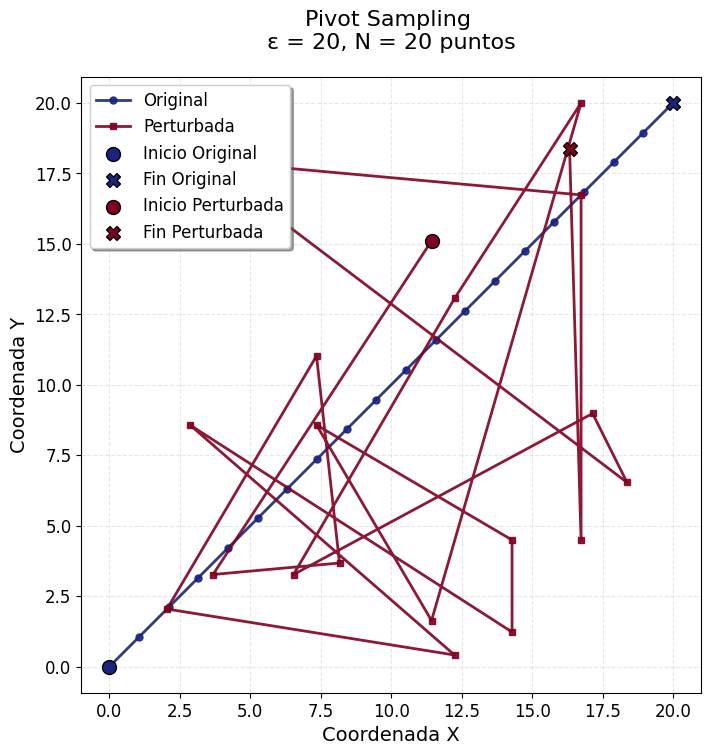

In [55]:
import matplotlib.pyplot as plt

# Crear una trayectoria de ejemplo (línea recta de (0,0) a (10,10))
original_trajectory = [(i, i) for i in np.linspace(0, 20, 20)]

# Crear un dominio espacial discreto (rejilla 50x50)
grid_size = 50
x_coords = np.linspace(0, 20, grid_size)
y_coords = np.linspace(0, 20, grid_size)
domain = [(x, y) for x in x_coords for y in y_coords]

# Inicializar el algoritmo Pivot Sampling
ps = PivotSampling(epsilon=49)

# Aplicar el algoritmo a la trayectoria
perturbed_trajectory = ps.perturb_trajectory(original_trajectory, domain)
# ------------------ Visualización estilo Laplace ------------------

# Convertir listas de tuplas a arrays para facilidad
original_np = np.array(original_trajectory)
perturbed_np = np.array(perturbed_trajectory)

# Configuración de estilo similar a tu gráfica
plt.rcParams.update({
 "figure.figsize": (8, 8),
 "axes.titlesize": 16,
 "axes.labelsize": 14,
 "xtick.labelsize": 12,
 "ytick.labelsize": 12,
 "legend.fontsize": 12,
 "lines.linewidth": 2,
 "axes.grid": True,
 "grid.alpha": 0.3,
 "grid.linestyle": "--"
})

fig, ax = plt.subplots()

color_original = "#1a237e" # Azul rey
color_perturbada = "#800020" # Vino

# Trayectoria original
ax.plot(original_np[:, 0], original_np[:, 1],
 color=color_original, marker="o", markersize=5, label="Original", alpha=0.9)

# Trayectoria perturbada
ax.plot(perturbed_np[:, 0], perturbed_np[:, 1],
 color=color_perturbada, marker="s", markersize=5, label="Perturbada", alpha=0.9)

# Inicio y fin
ax.scatter(*original_np[0], color=color_original, s=100, edgecolor="k", label="Inicio Original", zorder=5)
ax.scatter(*original_np[-1], color=color_original, s=100, edgecolor="k", marker="X", label="Fin Original", zorder=5)
ax.scatter(*perturbed_np[0], color=color_perturbada, s=100, edgecolor="k", label="Inicio Perturbada", zorder=5)
ax.scatter(*perturbed_np[-1], color=color_perturbada, s=100, edgecolor="k", marker="X", label="Fin Perturbada", zorder=5)

# Título con ε y número de puntos
ax.set_title(f"Pivot Sampling \nε = 20, N = {len(original_trajectory)} puntos", pad=20)

# Etiquetas
ax.set_xlabel("Coordenada X")
ax.set_ylabel("Coordenada Y")

# Ejes iguales y cuadrícula
ax.axis("equal")
ax.grid(True, linestyle="--", alpha=0.3)

# Leyenda con sombra
ax.legend(loc="best", frameon=True, shadow=True)

plt.show()

## Grafica dos trayectorias

In [37]:
import folium
from folium import plugins

ruta_archivo = "../data/raw/geolife_trajectories_1_3/Data/000/Trajectory/20081023025304.plt"
original_trajectory = cargar_trayectoria_real(ruta_archivo)
 
# Crear dominio alrededor de la trayectoria (100m de margen)
domain = crear_dominio_espacial(original_trajectory, radio=100.0)
print(len(original_trajectory), "puntos en el dominio")

# Epsilon seleccionado 
# Problema: Un epsilon muy pequeño genera ruido excesivo
# El presupuesto de privacidad se rompe, escalar epsilon () se necesita un epsilon proporcional al numero de puntos de la trayectoria
# Discusion respecto a la utilidad al caso de los usos especficos. Estilo wheels, densidad de las trayectorias en rutas, metrica util de utilidad 
# Definir epsilons suficientemente grandes de acuerdo al numero de puntos de la trayectoria, y el tipo de metodo y para que lo quiero usar 
# Experimentos donde voy ajustando el epsilon, parametro de comparacion inicial con el epsilon, que no haya el ruido de que tan larga es la trayectoria 
# Pruebas 
epsilon_seleccionado = 908.0

ps = PivotSampling(epsilon= epsilon_seleccionado)

# Aplicar perturbación
perturbed_trajectory = ps.perturb_trajectory(original_trajectory, domain)

# Crear un mapa centrado en el primer punto de la trayectoria original
map_center = original_trajectory[0]
m = folium.Map(location=map_center, zoom_start=16)

# Agregar la trayectoria original (azul)
folium.PolyLine(
 locations=original_trajectory,
 color='blue',
 weight=3,
 opacity=0.7,
 tooltip='Original'
).add_to(m)

# Agregar la trayectoria perturbada (rojo)
folium.PolyLine(
 locations=perturbed_trajectory,
 color='red',
 weight=3,
 opacity=0.7,
 tooltip='Perturbada'
).add_to(m)

# Conectar puntos originales con perturbados 
for orig, pert in zip(original_trajectory, perturbed_trajectory):
 folium.PolyLine(
 locations=[orig, pert],
 color='green',
 weight=1,
 opacity=0.3
 ).add_to(m)


folium.Marker(location=original_trajectory[0], popup="Inicio Original", icon=folium.Icon(color='blue')).add_to(m)
folium.Marker(location=perturbed_trajectory[0], popup="Inicio Perturbada", icon=folium.Icon(color='red')).add_to(m)

# Mostrar mapa
m.save("../artifacts/pivot/maps/trayectoria_pivot_mapa.html")

distancias = [ps.haversine_distance(orig, pert) 
 for orig, pert in zip(original_trajectory, perturbed_trajectory)]

distancia_media = sum(distancias) / len(distancias)
print(f"Distancia media de perturbación: {distancia_media:.2f} metros")


908 puntos en el dominio
Distancia media de perturbación: 137.77 metros


## Poblar Base de datos

In [5]:
import time
import math
import numpy as np
import pandas as pd
from typing import List, Tuple
from scipy.spatial.distance import directed_hausdorff

# ---- TIPOS ----
Point = Tuple[float, float]
Trajectory = List[Point]

# ---- MÉTRICAS ----
def haversine_distance(p1: Point, p2: Point) -> float:
 R = 6371000.0
 lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
 lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
 dlat = lat2 - lat1
 dlon = lon2 - lon1
 a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
 return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

def trajectory_length(traj: Trajectory) -> float:
 return sum(haversine_distance(traj[i], traj[i+1]) for i in range(len(traj)-1))

def mean_displacement(original: Trajectory, perturbed: Trajectory) -> float:
 return np.mean([haversine_distance(o, p) for o, p in zip(original, perturbed)])

def max_displacement(original: Trajectory, perturbed: Trajectory) -> float:
 return np.max([haversine_distance(o, p) for o, p in zip(original, perturbed)])

def std_displacement(original: Trajectory, perturbed: Trajectory) -> float:
 return np.std([haversine_distance(o, p) for o, p in zip(original, perturbed)])

def trajectory_length_error(original: Trajectory, perturbed: Trajectory) -> float:
 return abs(trajectory_length(original) - trajectory_length(perturbed))

def mean_direction_error(original: Trajectory, perturbed: Trajectory) -> float:
 def bearing(p1: Point, p2: Point) -> float:
 lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
 lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
 dlon = lon2 - lon1
 y = math.sin(dlon) * math.cos(lat2)
 x = math.cos(lat1)*math.sin(lat2) - math.sin(lat1)*math.cos(lat2)*math.cos(dlon)
 return math.atan2(y, x)
 
 errors = []
 for i in range(len(original)-1):
 theta_orig = bearing(original[i], original[i+1])
 theta_pert = bearing(perturbed[i], perturbed[i+1])
 errors.append(abs(theta_orig - theta_pert))
 return np.mean(errors)

def hausdorff_distance(original: Trajectory, perturbed: Trajectory) -> float:
 a = np.array(original)
 b = np.array(perturbed)
 return max(directed_hausdorff(a, b)[0], directed_hausdorff(b, a)[0])

# ---- EVALUADOR ----
def evaluate_method(method_name: str, original: Trajectory, perturbed: Trajectory, runtime: float, epsilon: float) -> dict:
 return {
 "Método": method_name,
 "Tamaño Trayectoria": len(original),
 "Epsilon": epsilon,
 "Distancia Media (m)": mean_displacement(original, perturbed),
 "Distancia Máx (m)": max_displacement(original, perturbed),
 "Desv. Estándar (m)": std_displacement(original, perturbed),
 "Error Longitud (m)": trajectory_length_error(original, perturbed),
 "Error Dirección (rad)": mean_direction_error(original, perturbed),
 "Hausdorff (m)": hausdorff_distance(original, perturbed),
 "Tiempo (s)": runtime
 }
def get_selected_indices(traj_length: int) -> List[int]:
 step = traj_length // 5 # tamaño de cada tramo
 indices = []
 
 for i in range(1, 6): # 1 a 5 (porque no queremos incluir 0)
 end_point = i * step
 if end_point <= traj_length:
 indices.append(end_point)
 
 mid_point = (i * step) - (step // 2)
 if mid_point > 0 and mid_point < traj_length:
 indices.append(mid_point)
 
 return sorted(set(indices))

# ---- CARGAR DATOS ----
ruta_archivo = "../data/raw/geolife_trajectories_1_3/Data/000/Trajectory/20081023025304.plt"
original_trajectory = cargar_trayectoria_real(ruta_archivo)
domain = crear_dominio_espacial(original_trajectory, radio=100.0)

# ---- EJECUTAR PRUEBAS (10 corridas por epsilon) ----
max_epsilon = 5 * len(original_trajectory)
epsilons = get_selected_indices(len(original_trajectory)*5)
results = []
N_RUNS = 10

for epsilon in epsilons:
 for run in range(N_RUNS):
 ps = PivotSampling(epsilon=epsilon)
 
 start_time = time.time()
 perturbed_trajectory = ps.perturb_trajectory(original_trajectory, domain)
 runtime = time.time() - start_time
 
 result = evaluate_method("PivotSampling", original_trajectory, perturbed_trajectory, runtime, epsilon)
 result["Run"] = run # Guardar el número de corrida
 results.append(result)
 print(f"Epsilon: {epsilon}, Run: {run+1}/{N_RUNS} completado.")


# ---- GUARDAR RESULTADOS ----
df_results = pd.DataFrame(results)
print(df_results)

df_results.to_csv("../artifacts/pivot/analysis_outputs/pivot_summary_metrics.csv", index=False)


Epsilon: 454, Run: 1/10 completado.
Epsilon: 454, Run: 2/10 completado.
Epsilon: 454, Run: 3/10 completado.
Epsilon: 454, Run: 4/10 completado.
Epsilon: 454, Run: 5/10 completado.
Epsilon: 454, Run: 6/10 completado.
Epsilon: 454, Run: 7/10 completado.
Epsilon: 454, Run: 8/10 completado.
Epsilon: 454, Run: 9/10 completado.
Epsilon: 454, Run: 10/10 completado.
Epsilon: 908, Run: 1/10 completado.
Epsilon: 908, Run: 2/10 completado.
Epsilon: 908, Run: 3/10 completado.
Epsilon: 908, Run: 4/10 completado.
Epsilon: 908, Run: 5/10 completado.
Epsilon: 908, Run: 6/10 completado.
Epsilon: 908, Run: 7/10 completado.
Epsilon: 908, Run: 8/10 completado.
Epsilon: 908, Run: 9/10 completado.
Epsilon: 908, Run: 10/10 completado.
Epsilon: 1362, Run: 1/10 completado.
Epsilon: 1362, Run: 2/10 completado.
Epsilon: 1362, Run: 3/10 completado.
Epsilon: 1362, Run: 4/10 completado.
Epsilon: 1362, Run: 5/10 completado.
Epsilon: 1362, Run: 6/10 completado.
Epsilon: 1362, Run: 7/10 completado.
Epsilon: 1362, Run:

## Grafica base de datos


 Gráfica de Distancia Media (m)
Descripción: Promedio de la distancia entre trayectorias originales y aproximadas.



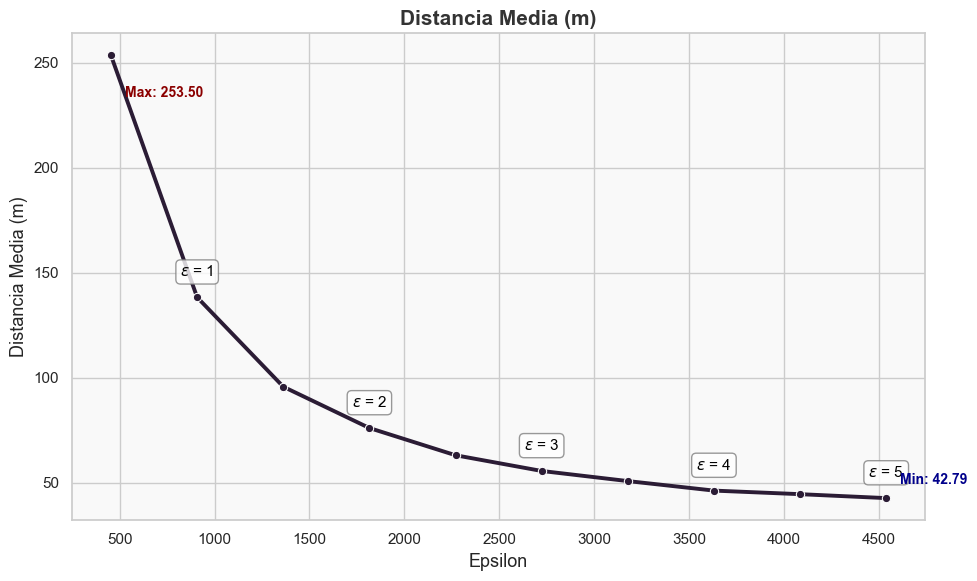


 Gráfica de Distancia Máx (m)
Descripción: Mayor distancia registrada entre dos trayectorias.



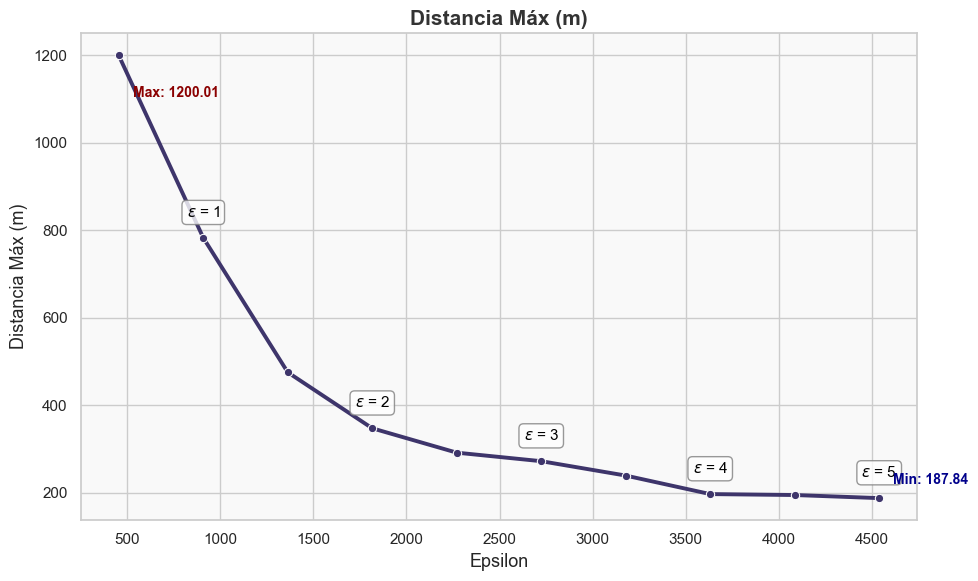


 Gráfica de Desv. Estándar (m)
Descripción: Variabilidad de la distancia entre las trayectorias.



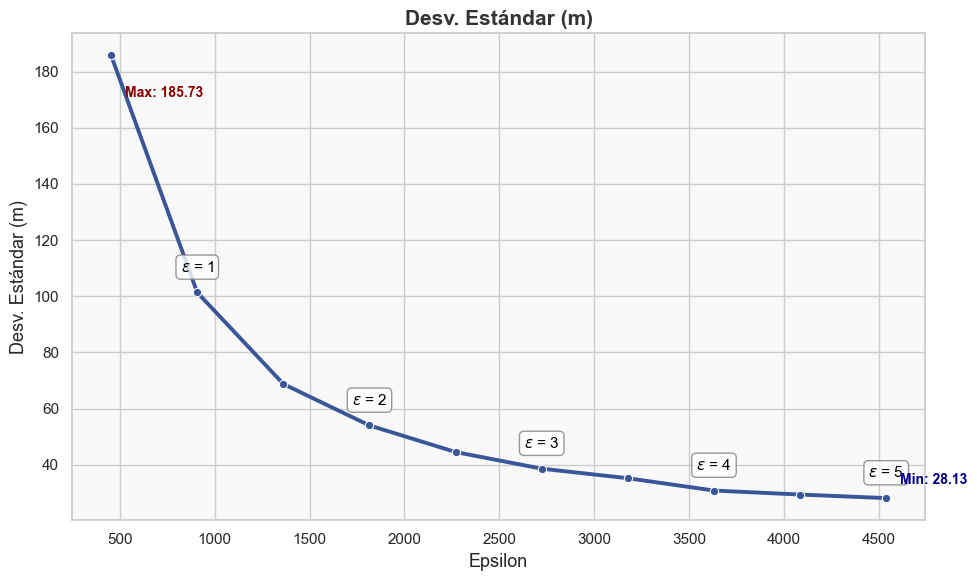


 Gráfica de Error Longitud (m)
Descripción: Diferencia en longitud total entre las trayectorias.



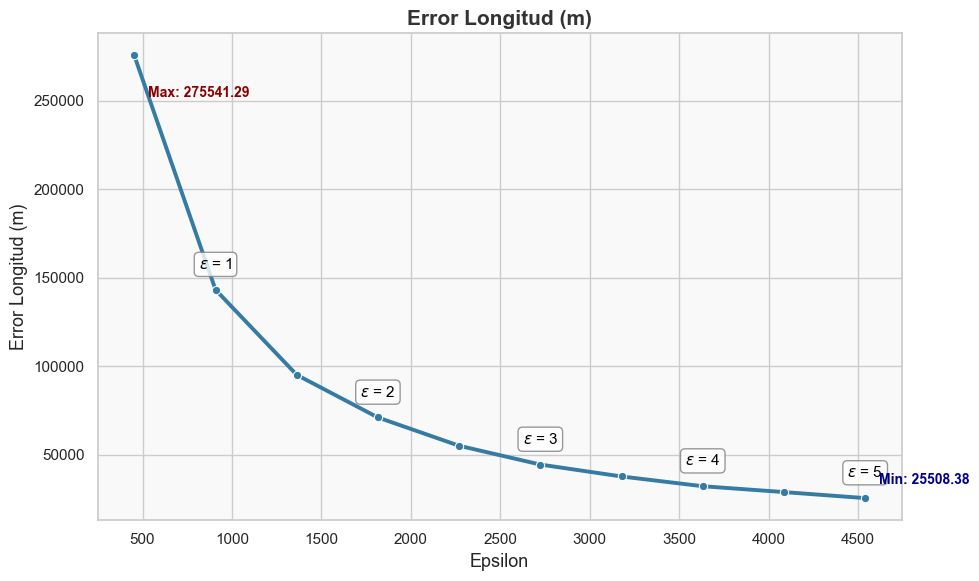


 Gráfica de Error Dirección (rad)
Descripción: Diferencia en orientación promedio entre las trayectorias.



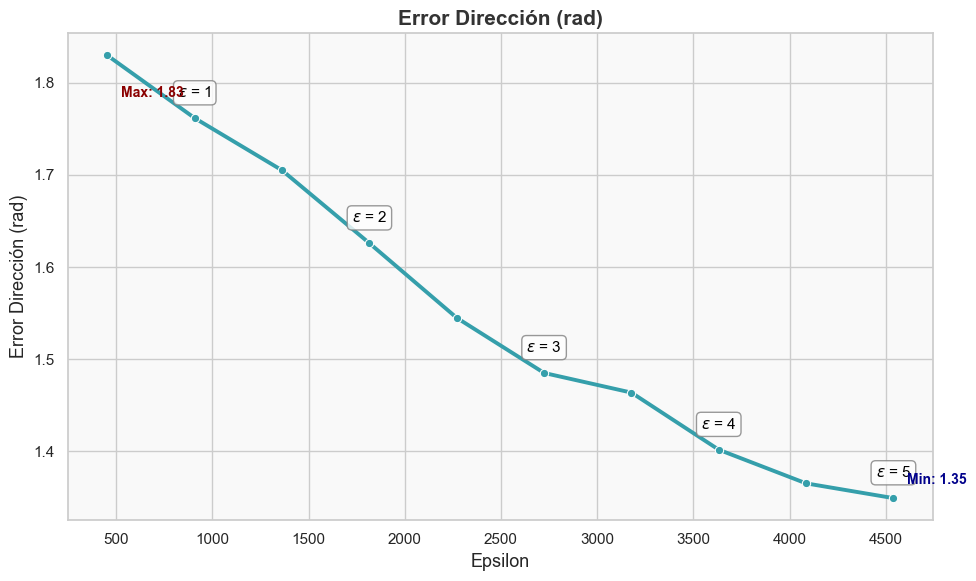


 Gráfica de Hausdorff (m)
Descripción: Distancia Hausdorff que mide la similitud entre trayectorias.



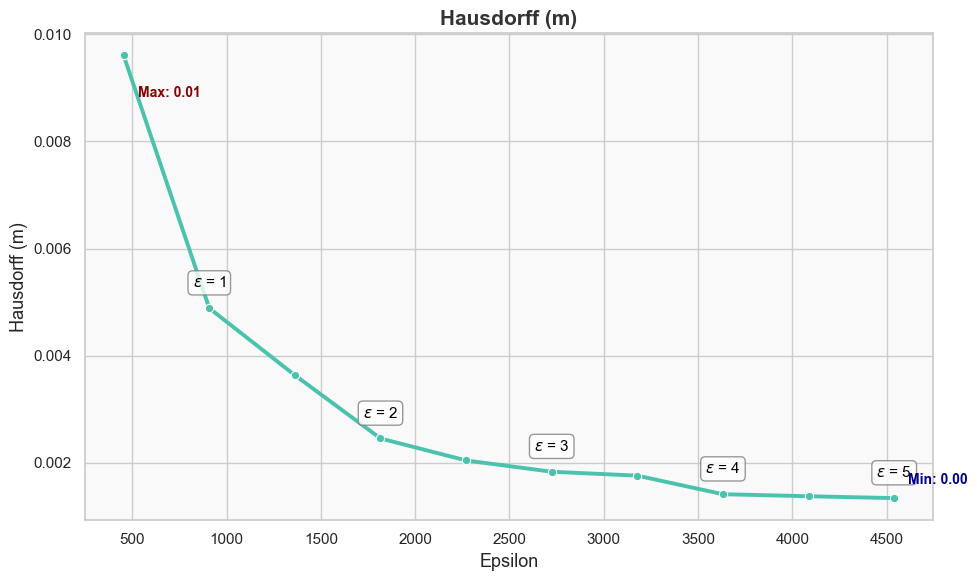


 Gráfica de Tiempo (s)
Descripción: Tiempo requerido para el procesamiento.



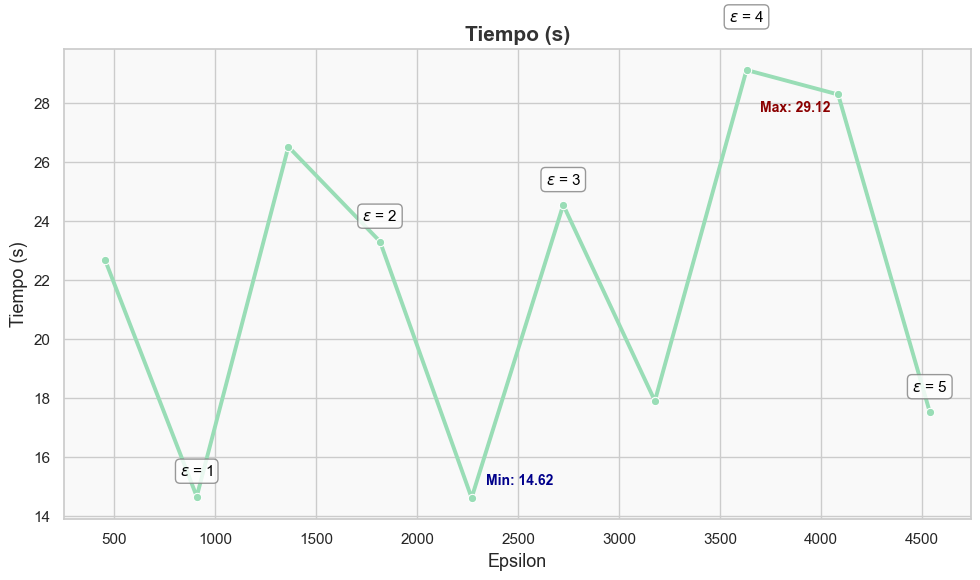

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leer datos
df = pd.read_csv("../artifacts/pivot/analysis_outputs/pivot_summary_metrics.csv")

# Agrupar por epsilon y promediar todas las métricas
df_avg = df.groupby("Epsilon", as_index=False).mean(numeric_only=True)

metricas = [
 "Distancia Media (m)",
 "Distancia Máx (m)",
 "Desv. Estándar (m)",
 "Error Longitud (m)",
 "Error Dirección (rad)",
 "Hausdorff (m)",
 "Tiempo (s)"
]

# Descripciones para cada métrica
descripciones = {
 "Distancia Media (m)": "Promedio de la distancia entre trayectorias originales y aproximadas.",
 "Distancia Máx (m)": "Mayor distancia registrada entre dos trayectorias.",
 "Desv. Estándar (m)": "Variabilidad de la distancia entre las trayectorias.",
 "Error Longitud (m)": "Diferencia en longitud total entre las trayectorias.",
 "Error Dirección (rad)": "Diferencia en orientación promedio entre las trayectorias.",
 "Hausdorff (m)": "Distancia Hausdorff que mide la similitud entre trayectorias.",
 "Tiempo (s)": "Tiempo requerido para el procesamiento."
}

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 13})

palette = sns.color_palette("mako", len(metricas))

# Índices y etiquetas para epsilon
annot_indices = [1, 3, 5, 7, 9]
epsilons_labels = [r'$\epsilon$ = 1', r'$\epsilon$ = 2', r'$\epsilon$ = 3', r'$\epsilon$ = 4', r'$\epsilon$ = 5']

for i, metrica in enumerate(metricas):
 print(f"\n Gráfica de {metrica}")
 print(f"Descripción: {descripciones[metrica]}\n")
 
 plt.figure(figsize=(10, 6))
 ax = sns.lineplot(data=df_avg, x="Epsilon", y=metrica, marker="o", linewidth=2.8, color=palette[i])
 
 ax.set_title(metrica, fontsize=15, fontweight="bold", color="#333333")
 ax.set_xlabel("Epsilon", fontsize=13)
 ax.set_ylabel(metrica, fontsize=13)
 ax.set_facecolor("#f9f9f9")
 
 # Mostrar números completos en el eje Y
 ax.ticklabel_format(style='plain', axis='y')
 
 # Anotaciones de epsilon (solo si hay suficientes puntos)
 for idx, label in zip(annot_indices, epsilons_labels):
 if idx < len(df_avg):
 x = df_avg["Epsilon"].iloc[idx]
 y = df_avg[metrica].iloc[idx]
 offset_y = 15
 if y == df_avg[metrica].max():
 offset_y += 20
 
 ax.annotate(label,
 xy=(x, y),
 xytext=(0, offset_y),
 textcoords="offset points",
 ha="center",
 fontsize=11,
 color="black",
 bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.8))
 
 # Anotaciones de máximo y mínimo
 max_val = df_avg[metrica].max()
 min_val = df_avg[metrica].min()
 max_idx = df_avg[metrica].idxmax()
 min_idx = df_avg[metrica].idxmin()
 
 ax.annotate(f"Max: {max_val:.2f}", xy=(df_avg["Epsilon"][max_idx], max_val),
 xytext=(10, -30), textcoords="offset points",
 fontsize=10, color="darkred", fontweight="bold")
 
 ax.annotate(f"Min: {min_val:.2f}", xy=(df_avg["Epsilon"][min_idx], min_val),
 xytext=(10, 10), textcoords="offset points",
 fontsize=10, color="darkblue", fontweight="bold")
 
 plt.tight_layout()
 plt.show()


# Generacion de matrices OD

In [4]:
pasos_m = [1000, 1500, 2000, 2500, 3000]

In [ ]:
import numpy as np
import os
from glob import glob
from scipy.sparse import dok_matrix
import pandas as pd
pasos_m = [1000, 1500, 2000, 2500, 3000]
# ----------------- Funciones auxiliares -----------------
def cargar_trayectoria_real(ruta_archivo):
 """Carga trayectoria desde archivo PLT de GeoLife"""
 latlons = []
 with open(ruta_archivo, "r", encoding="utf-8", errors="ignore") as f:
 for i, linea in enumerate(f):
 if i < 6: 
 continue # Saltar cabecera
 partes = linea.strip().split(",")
 try:
 latlons.append((float(partes[0]), float(partes[1])))
 except (ValueError, IndexError):
 continue
 return latlons

def latlon_a_celda(lat, lon, lat_min, lon_min, paso_m):
 """Convierte lat/lon a índice de celda"""
 paso_lat = paso_m / 111000
 paso_lon = paso_m / (111000 * np.cos(np.radians((lat_min + lat.max())/2)))
 i = ((lat - lat_min) // paso_lat).astype(int)
 j = ((lon - lon_min) // paso_lon).astype(int)
 return i, j

def obtener_celdas_unificadas(trayectorias, trayectorias_pert, paso_m):
 """Obtiene un diccionario con las celdas únicas"""
 todas_lats = np.concatenate([np.array(tray)[:,0] for tray in trayectorias + trayectorias_pert])
 todas_lons = np.concatenate([np.array(tray)[:,1] for tray in trayectorias + trayectorias_pert])
 lat_min, lon_min = todas_lats.min(), todas_lons.min()

 celdas = {}
 idx = 0
 for tray in trayectorias + trayectorias_pert:
 i, j = latlon_a_celda(np.array(tray)[:,0], np.array(tray)[:,1], lat_min, lon_min, paso_m)
 for c in zip(i, j):
 if c not in celdas:
 celdas[c] = idx
 idx += 1
 return celdas, lat_min, lon_min

def construir_matriz_od_sparse(trayectorias, celdas, lat_min, lon_min, paso_m):
 """Construye matriz OD dispersa"""
 n = len(celdas)
 OD = dok_matrix((n, n), dtype=int)
 for tray in trayectorias:
 i, j = latlon_a_celda(np.array(tray)[:,0], np.array(tray)[:,1], lat_min, lon_min, paso_m)
 origen = celdas[(i[0], j[0])]
 destino = celdas[(i[-1], j[-1])]
 OD[origen, destino] += 1
 return OD

# ----------------- Parámetros -----------------
carpeta_salida = "../artifacts/pivot/analysis_outputs"
os.makedirs(carpeta_salida, exist_ok=True)

# ----------------- Cargar trayectorias -----------------
ruta_carpeta = "../data/raw/geolife_trajectories_1_3/Data/002/Trajectory"
archivos_plt = glob(os.path.join(ruta_carpeta, "*.plt"))
trayectorias = [cargar_trayectoria_real(f) for f in archivos_plt if os.path.getsize(f) > 0]

# ----------------- Generar resultados -----------------
# ----------------- Generar resultados -----------------
for paso_m in pasos_m:
 for k in range(1, 6): # Multiplicadores del epsilon
 
 print(f"\nProcesando paso_m = {paso_m} | multiplicador k = {k}")

 archivo_od_original = f"{carpeta_salida}/OD_original_k{k}_paso{paso_m}.csv"
 archivo_od_perturbada = f"{carpeta_salida}/OD_perturbada_k{k}_paso{paso_m}.csv"
 archivo_celdas = f"{carpeta_salida}/celdas_k{k}_paso{paso_m}.csv"
 archivo_minimos = f"{carpeta_salida}/minimos_k{k}_paso{paso_m}.csv"

 # Saltar si ya existen todos los archivos
 if all(os.path.exists(f) for f in [archivo_od_original, archivo_od_perturbada, archivo_celdas, archivo_minimos]):
 print(f"⏩ Archivos ya existen, saltando paso_m={paso_m}, k={k}")
 continue

 trayectorias_pert = []
 for tray in trayectorias:
 epsilon = len(tray) * k
 pivot_sampler = PivotSampling(epsilon=epsilon)
 domain = crear_dominio_espacial(tray, radio=100.0)
 tray_pert = pivot_sampler.perturb_trajectory(tray, domain)
 trayectorias_pert.append(tray_pert)

 # Crear celdas y matrices OD
 celdas_unificadas, lat_min, lon_min = obtener_celdas_unificadas(
 trayectorias, trayectorias_pert, paso_m
 )
 OD_original = construir_matriz_od_sparse(trayectorias, celdas_unificadas, lat_min, lon_min, paso_m)
 OD_perturbada = construir_matriz_od_sparse(trayectorias_pert, celdas_unificadas, lat_min, lon_min, paso_m)

 # Guardar matrices OD
 pd.DataFrame(OD_original.toarray()).to_csv(archivo_od_original, index=False)
 pd.DataFrame(OD_perturbada.toarray()).to_csv(archivo_od_perturbada, index=False)

 # Guardar celdas
 df_celdas = pd.DataFrame(
 [(clave[0], clave[1], valor) for clave, valor in celdas_unificadas.items()],
 columns=["i", "j", "indice"]
 )
 df_celdas.to_csv(archivo_celdas, index=False)

 # Guardar lat_min y lon_min
 df_minimos = pd.DataFrame({
 "lat_min": [lat_min],
 "lon_min": [lon_min]
 })
 df_minimos.to_csv(archivo_minimos, index=False)

 print(f" Archivos generados para k={k}, paso_m={paso_m}:")
 print(f" - {archivo_od_original}")
 print(f" - {archivo_od_perturbada}")
 print(f" - {archivo_celdas}")
 print(f" - {archivo_minimos}")

print("\n Todos los archivos generados y guardados en '../artifacts/pivot/analysis_outputs/'")



Procesando paso_m = 1000 | multiplicador k = 1
⏩ Archivos ya existen, saltando paso_m=1000, k=1

Procesando paso_m = 1000 | multiplicador k = 2
⏩ Archivos ya existen, saltando paso_m=1000, k=2

Procesando paso_m = 1000 | multiplicador k = 3
⏩ Archivos ya existen, saltando paso_m=1000, k=3

Procesando paso_m = 1000 | multiplicador k = 4
⏩ Archivos ya existen, saltando paso_m=1000, k=4

Procesando paso_m = 1000 | multiplicador k = 5
⏩ Archivos ya existen, saltando paso_m=1000, k=5

Procesando paso_m = 1500 | multiplicador k = 1
⏩ Archivos ya existen, saltando paso_m=1500, k=1

Procesando paso_m = 1500 | multiplicador k = 2
⏩ Archivos ya existen, saltando paso_m=1500, k=2

Procesando paso_m = 1500 | multiplicador k = 3
⏩ Archivos ya existen, saltando paso_m=1500, k=3

Procesando paso_m = 1500 | multiplicador k = 4
⏩ Archivos ya existen, saltando paso_m=1500, k=4

Procesando paso_m = 1500 | multiplicador k = 5
⏩ Archivos ya existen, saltando paso_m=1500, k=5

Procesando paso_m = 2000 | mu

# Grafica de trayectorias

In [ ]:
import folium

# ---------- MAPA 1: Trayectorias originales ----------
lat_c, lon_c = trayectorias_originales_latlon[0][0]
mapa_original = folium.Map(location=[lat_c, lon_c], zoom_start=12)

for idx, tray in enumerate(trayectorias_originales_latlon):
 coords = [(lat, lon) for lat, lon in tray]

 # Dibujar la trayectoria
 folium.PolyLine(coords, color="blue", weight=2, opacity=0.7).add_to(mapa_original)

 # Marcar inicio (verde)
 folium.CircleMarker(
 location=coords[0],
 radius=4,
 color="green",
 fill=True,
 fill_opacity=1,
 popup=f"Inicio Trayectoria {idx}"
 ).add_to(mapa_original)

 # Marcar fin (rojo)
 folium.CircleMarker(
 location=coords[-1],
 radius=4,
 color="red",
 fill=True,
 fill_opacity=1,
 popup=f"Fin Trayectoria {idx}"
 ).add_to(mapa_original)

mapa_original.save("../artifacts/pivot/maps/mapa_trayectorias_originales.html")


# ---------- MAPA 2: Trayectorias perturbadas ----------
lat_c2, lon_c2 = trayectorias_perturbadas_latlon[0][0]
mapa_perturbado = folium.Map(location=[lat_c2, lon_c2], zoom_start=12)

for idx, tray in enumerate(trayectorias_perturbadas_latlon):
 coords = [(lat, lon) for lat, lon in tray]

 # Dibujar la trayectoria
 folium.PolyLine(coords, color="red", weight=2, opacity=0.7).add_to(mapa_perturbado)

 # Marcar inicio (verde)
 folium.CircleMarker(
 location=coords[0],
 radius=4,
 color="green",
 fill=True,
 fill_opacity=1,
 popup=f"Inicio Trayectoria {idx}"
 ).add_to(mapa_perturbado)

 # Marcar fin (black)
 folium.CircleMarker(
 location=coords[-1],
 radius=4,
 color="black",
 fill=True,
 fill_opacity=1,
 popup=f"Fin Trayectoria {idx}"
 ).add_to(mapa_perturbado)

mapa_perturbado.save("../artifacts/pivot/maps/mapa_trayectorias_perturbadas.html")

print(" Mapas generados con INICIO (verde) y FIN (rojo/negro).")


# Archivo a usar

In [1]:
import os
import pandas as pd
import numpy as np
from glob import glob

k=1
paso_m=3000

In [2]:
def cargar_trayectoria(ruta_archivo):
 latlons = []
 with open(ruta_archivo, "r", encoding="utf-8", errors="ignore") as f:
 for i, linea in enumerate(f):
 if i < 6: continue # Saltar cabecera
 partes = linea.strip().split(",")
 try:
 latlons.append((float(partes[0]), float(partes[1])))
 except (ValueError, IndexError):
 continue
 return np.array(latlons)

In [3]:
ruta_carpeta = "../data/raw/geolife_trajectories_1_3/Data/002/Trajectory"
archivos_plt = glob(os.path.join(ruta_carpeta, "*.plt"))
trayectorias = [cargar_trayectoria(f) for f in archivos_plt if len(cargar_trayectoria(f)) > 0]



carpeta_salida = "../artifacts/pivot/analysis_outputs"

# Rutas de los archivos
archivo_od_original = os.path.join(carpeta_salida, f"OD_original_k{k}_paso{paso_m}.csv")
archivo_od_perturbada = os.path.join(carpeta_salida, f"OD_perturbada_k{k}_paso{paso_m}.csv")
archivo_celdas = os.path.join(carpeta_salida, f"celdas_k{k}_paso{paso_m}.csv")
archivo_minimos = os.path.join(carpeta_salida, f"minimos_k{k}_paso{paso_m}.csv")

# Leer las matrices OD
OD_original = pd.read_csv(archivo_od_original).values
OD_perturbada = pd.read_csv(archivo_od_perturbada).values

# Leer las celdas y reconstruir el diccionario
df_celdas = pd.read_csv(archivo_celdas)
celdas_unificadas = {(row["i"], row["j"]): row["indice"] for _, row in df_celdas.iterrows()}

# Leer lat_min y lon_min desde su archivo
df_minimos = pd.read_csv(archivo_minimos)
lat_min = df_minimos["lat_min"].iloc[0]
lon_min = df_minimos["lon_min"].iloc[0]

# Matrices Origen - Destino

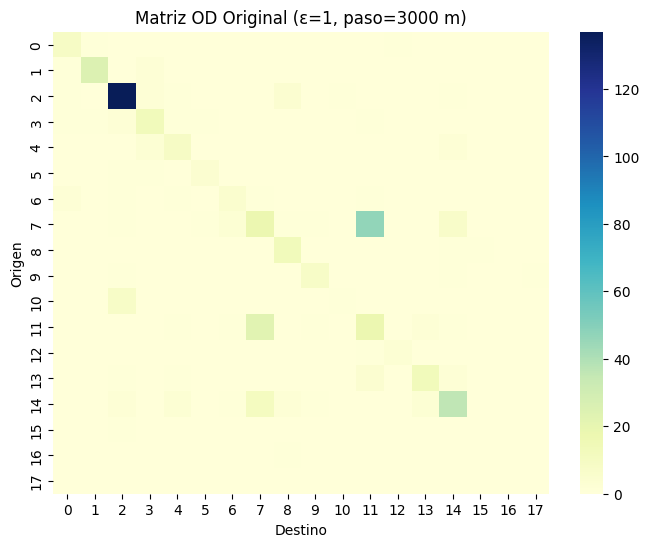

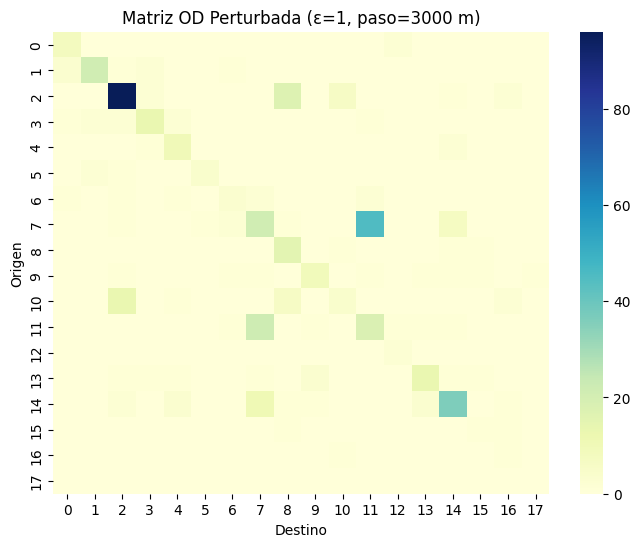

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Graficar heatmap para OD original
plt.figure(figsize=(8,6))
sns.heatmap(OD_original, cmap="YlGnBu", cbar=True)
plt.title(f"Matriz OD Original (ε={epsilon}, paso={paso_m} m)")
plt.xlabel("Destino")
plt.ylabel("Origen")
plt.show()

# Graficar heatmap para OD perturbada
plt.figure(figsize=(8,6))
sns.heatmap(OD_perturbada, cmap="YlGnBu", cbar=True)
plt.title(f"Matriz OD Perturbada (ε={epsilon}, paso={paso_m} m)")
plt.xlabel("Destino")
plt.ylabel("Origen")
plt.show()


# Mapa de calor por zonas mas transitadas

In [17]:
import folium
from folium import plugins
from branca.colormap import LinearColormap
import numpy as np
import matplotlib.pyplot as plt



def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Cantidad de viajes por celda
viajes_por_celda = np.array([OD_original[i,i] for i in range(len(celdas_unificadas))])

# Crear mapa
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Crear colormap usando matplotlib 'plasma'
colormap = LinearColormap(
 colors=[plt.cm.plasma(i/255)[:3] for i in range(0,256,5)], # colores del 0 al 255
 vmin=0,
 vmax=viajes_por_celda.max()
)
colormap.caption = "Número de viajes por celda"
colormap.add_to(m)

# Dibujar celdas
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))
 
 # Color según número de viajes
 intensidad = viajes_por_celda[idx]
 color_hex = colormap(intensidad)
 
 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_hex,
 fill=True,
 fill_color=color_hex,
 fill_opacity=0.7,
 tooltip=f"Zona: {idx}\nViajes: {viajes_por_celda[idx]}"
 ).add_to(m)

# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_beijing_original.html")


In [ ]:
import folium
from folium import plugins
from branca.colormap import LinearColormap
import numpy as np
import matplotlib.pyplot as plt



def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Cantidad de viajes por celda
viajes_por_celda = np.array([OD_perturbada[i,i] for i in range(len(celdas_unificadas))])

# Crear mapa
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Crear colormap usando matplotlib 'plasma'
colormap = LinearColormap(
 colors=[plt.cm.plasma(i/255)[:3] for i in range(0,256,5)], # colores del 0 al 255
 vmin=0,
 vmax=viajes_por_celda.max()
)
colormap.caption = "Número de viajes por celda"
colormap.add_to(m)

# Dibujar celdas
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))
 
 # Color según número de viajes
 intensidad = viajes_por_celda[idx]
 color_hex = colormap(intensidad)
 
 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_hex,
 fill=True,
 fill_color=color_hex,
 fill_opacity=0.7,
 tooltip=f"Zona: {idx}\nViajes: {viajes_por_celda[idx]}"
 ).add_to(m)

# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_beijing_perturbado.html")


# Mapa de calor por destino 

In [18]:
import folium
from folium import plugins
from branca.colormap import LinearColormap
import numpy as np
import matplotlib.pyplot as plt

def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Ahora calculamos los viajes por celda destino (sumando por columnas)
viajes_por_celda = np.array([OD_original[:, i].sum() for i in range(len(celdas_unificadas))])

# Crear mapa centrado en el área
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Crear colormap usando matplotlib 'plasma'
colormap = LinearColormap(
 colors=[plt.cm.plasma(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda.max()
)
colormap.caption = "Número de viajes con destino en celda"
colormap.add_to(m)

# Dibujar celdas
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))
 
 intensidad = viajes_por_celda[idx]
 color_hex = colormap(intensidad)
 
 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_hex,
 fill=True,
 fill_color=color_hex,
 fill_opacity=0.7,
 tooltip=f"Zona destino: {idx}\nViajes recibidos: {viajes_por_celda[idx]}"
 ).add_to(m)

# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_destino_original.html")
# Ahora calculamos los viajes por celda destino (sumando por columnas)
viajes_por_celda = np.array([OD_original[:, i].sum() for i in range(len(celdas_unificadas))])

# Imprimir en terminal
print("=== VIAJES POR CELDA DESTINO ===")
for idx, num_viajes in enumerate(viajes_por_celda):
 print(f"Celda destino {idx}: {num_viajes} viajes")

print("\nTOTAL de viajes considerados:", viajes_por_celda.sum())

=== VIAJES POR CELDA DESTINO ===
Celda destino 0: 14 viajes
Celda destino 1: 27 viajes
Celda destino 2: 155 viajes
Celda destino 3: 21 viajes
Celda destino 4: 17 viajes
Celda destino 5: 6 viajes
Celda destino 6: 10 viajes
Celda destino 7: 53 viajes
Celda destino 8: 21 viajes
Celda destino 9: 11 viajes
Celda destino 10: 2 viajes
Celda destino 11: 72 viajes
Celda destino 12: 4 viajes
Celda destino 13: 18 viajes
Celda destino 14: 51 viajes
Celda destino 15: 1 viajes
Celda destino 16: 0 viajes
Celda destino 17: 1 viajes

TOTAL de viajes considerados: 484


In [19]:
import folium
from folium import plugins
from branca.colormap import LinearColormap
import numpy as np
import matplotlib.pyplot as plt

def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Cantidad de viajes por celda destino (sumando columnas)
viajes_por_celda = np.array([OD_perturbada[:, i].sum() for i in range(len(celdas_unificadas))])

# Imprimir número de viajes por celda y total
print("=== VIAJES POR CELDA DESTINO (PERTURBADA) ===")
for idx, num_viajes in enumerate(viajes_por_celda):
 print(f"Celda destino {idx}: {num_viajes} viajes")
print("TOTAL de viajes considerados:", viajes_por_celda.sum())

# Crear mapa centrado
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Crear colormap usando matplotlib 'plasma'
colormap = LinearColormap(
 colors=[plt.cm.plasma(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda.max()
)
colormap.caption = "Número de viajes destino por celda (perturbada)"
colormap.add_to(m)

# Dibujar celdas destino
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))
 
 intensidad = viajes_por_celda[idx]
 color_hex = colormap(intensidad)
 
 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_hex,
 fill=True,
 fill_color=color_hex,
 fill_opacity=0.9,
 tooltip=f"Celda destino: {idx}\nViajes recibidos: {intensidad}"
 ).add_to(m)

# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_destino_perturbado.html")
# Ahora calculamos los viajes por celda destino (sumando por columnas)
viajes_por_celda = np.array([OD_original[:, i].sum() for i in range(len(celdas_unificadas))])

# Imprimir en terminal
print("=== VIAJES POR CELDA DESTINO ===")
for idx, num_viajes in enumerate(viajes_por_celda):
 print(f"Celda destino {idx}: {num_viajes} viajes")

print("\nTOTAL de viajes considerados:", viajes_por_celda.sum())

=== VIAJES POR CELDA DESTINO (PERTURBADA) ===
Celda destino 0: 13 viajes
Celda destino 1: 25 viajes
Celda destino 2: 119 viajes
Celda destino 3: 19 viajes
Celda destino 4: 18 viajes
Celda destino 5: 5 viajes
Celda destino 6: 8 viajes
Celda destino 7: 58 viajes
Celda destino 8: 41 viajes
Celda destino 9: 14 viajes
Celda destino 10: 12 viajes
Celda destino 11: 67 viajes
Celda destino 12: 5 viajes
Celda destino 13: 18 viajes
Celda destino 14: 50 viajes
Celda destino 15: 4 viajes
Celda destino 16: 7 viajes
Celda destino 17: 1 viajes
TOTAL de viajes considerados: 484
=== VIAJES POR CELDA DESTINO ===
Celda destino 0: 14 viajes
Celda destino 1: 27 viajes
Celda destino 2: 155 viajes
Celda destino 3: 21 viajes
Celda destino 4: 17 viajes
Celda destino 5: 6 viajes
Celda destino 6: 10 viajes
Celda destino 7: 53 viajes
Celda destino 8: 21 viajes
Celda destino 9: 11 viajes
Celda destino 10: 2 viajes
Celda destino 11: 72 viajes
Celda destino 12: 4 viajes
Celda destino 13: 18 viajes
Celda destino 14: 

# Celdas Origen Mapa de Calor

In [20]:
import folium
from folium import plugins
from branca.colormap import LinearColormap
import numpy as np
import matplotlib.pyplot as plt

def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Cantidad de viajes por celda origen (sumando filas)
viajes_por_celda_origen = np.array([OD_original[i,:].sum() for i in range(len(celdas_unificadas))])

# Imprimir en terminal
print("=== VIAJES POR CELDA ORIGEN ===")
for idx, num_viajes in enumerate(viajes_por_celda_origen):
 print(f"Celda origen {idx}: {num_viajes} viajes")
print("\nTOTAL de viajes desde todas las celdas origen:", viajes_por_celda_origen.sum())

# Crear mapa centrado en el área
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Crear colormap usando matplotlib 'plasma'
colormap = LinearColormap(
 colors=[plt.cm.plasma(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_origen.max()
)
colormap.caption = "Número de viajes desde celda origen"
colormap.add_to(m)

# Dibujar celdas origen
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))
 
 intensidad = viajes_por_celda_origen[idx]
 color_hex = colormap(intensidad)
 
 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_hex,
 fill=True,
 fill_color=color_hex,
 fill_opacity=0.9,
 tooltip=f"Celda origen: {idx}\nViajes enviados: {intensidad}"
 ).add_to(m)

# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_origen_original.html")


=== VIAJES POR CELDA ORIGEN ===
Celda origen 0: 11 viajes
Celda origen 1: 28 viajes
Celda origen 2: 147 viajes
Celda origen 3: 20 viajes
Celda origen 4: 14 viajes
Celda origen 5: 6 viajes
Celda origen 6: 11 viajes
Celda origen 7: 79 viajes
Celda origen 8: 15 viajes
Celda origen 9: 11 viajes
Celda origen 10: 9 viajes
Celda origen 11: 47 viajes
Celda origen 12: 4 viajes
Celda origen 13: 21 viajes
Celda origen 14: 59 viajes
Celda origen 15: 1 viajes
Celda origen 16: 1 viajes
Celda origen 17: 0 viajes

TOTAL de viajes desde todas las celdas origen: 484


In [ ]:
import folium
from folium import plugins
from branca.colormap import LinearColormap
import numpy as np
import matplotlib.pyplot as plt

def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Cantidad de viajes por celda origen (sumando filas)
viajes_por_celda_origen = np.array([OD_perturbada[i,:].sum() for i in range(len(celdas_unificadas))])

# Imprimir número de viajes por celda origen y total
print("=== VIAJES POR CELDA ORIGEN (PERTURBADA) ===")
for idx, num_viajes in enumerate(viajes_por_celda_origen):
 print(f"Celda origen {idx}: {num_viajes} viajes")
print("TOTAL de viajes desde todas las celdas origen:", viajes_por_celda_origen.sum())

# Crear mapa centrado
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Crear colormap usando matplotlib 'plasma'
colormap = LinearColormap(
 colors=[plt.cm.plasma(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_origen.max()
)
colormap.caption = "Número de viajes desde celda origen (perturbada)"
colormap.add_to(m)

# Dibujar celdas origen
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))
 
 intensidad = viajes_por_celda_origen[idx]
 color_hex = colormap(intensidad)
 
 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_hex,
 fill=True,
 fill_color=color_hex,
 fill_opacity=0.9,
 tooltip=f"Celda origen: {idx}\nViajes enviados: {intensidad}"
 ).add_to(m)

# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_origen_perturbado.html")


# Mapa con trayectorias

In [21]:
import folium
from folium import plugins
from branca.colormap import LinearColormap
import numpy as np
import matplotlib.pyplot as plt

def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Convertir sparse matrix a numpy array
OD_array = OD_original

# Viajes por celda origen y destino
viajes_por_celda_origen = np.array([OD_array[i,:].sum() for i in range(len(celdas_unificadas))])
viajes_por_celda_destino = np.array([OD_array[:, j].sum() for j in range(len(celdas_unificadas))])

# Crear mapa centrado
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Colormaps
colormap_origen = LinearColormap(
 colors=[plt.cm.Blues(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_origen.max()
)
colormap_origen.caption = "Viajes desde celda origen"
colormap_origen.add_to(m)

colormap_destino = LinearColormap(
 colors=[plt.cm.Reds(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_destino.max()
)
colormap_destino.caption = "Viajes hacia celda destino"
colormap_destino.add_to(m)

# Dibujar celdas origen
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))

 intensidad_origen = viajes_por_celda_origen[idx]
 color_origen = colormap_origen(intensidad_origen)

 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_origen,
 fill=True,
 fill_color=color_origen,
 fill_opacity=0.6,
 tooltip=f"Celda origen: {idx}\nViajes enviados: {intensidad_origen}"
 ).add_to(m)

# Dibujar celdas destino
# Dibujar celdas con info de origen y destino
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))

 intensidad_origen = viajes_por_celda_origen[idx]
 intensidad_destino = viajes_por_celda_destino[idx]

 # Color combinado (puedes elegir la media de ambos colores)
 color_origen = colormap_origen(intensidad_origen)
 color_destino = colormap_destino(intensidad_destino)
 # Aquí hacemos un color "promedio" visual simple mezclando ambos (aprox)
 color_combinado = f'#{int((int(color_origen[1:3],16)+int(color_destino[1:3],16))/2):02x}' \
 f'{int((int(color_origen[3:5],16)+int(color_destino[3:5],16))/2):02x}' \
 f'{int((int(color_origen[5:7],16)+int(color_destino[5:7],16))/2):02x}'

 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_combinado,
 fill=True,
 fill_color=color_combinado,
 fill_opacity=0.6,
 tooltip=(f"Celda: {idx}\n"
 f"Viajes enviados: {intensidad_origen}\n"
 f"Viajes recibidos: {intensidad_destino}")
 ).add_to(m)


# Dibujar líneas desde origen a destino
max_viajes = OD_array.max() # para normalizar el grosor
for i in range(len(celdas_unificadas)):
 for j in range(len(celdas_unificadas)):
 if OD_array[i, j] > 0:
 lat_i, lon_i = celda_a_latlon_centro(*list(celdas_unificadas.keys())[i], lat_min, lon_min, paso_m)
 lat_j, lon_j = celda_a_latlon_centro(*list(celdas_unificadas.keys())[j], lat_min, lon_min, paso_m)
 folium.PolyLine(
 locations=[[lat_i, lon_i], [lat_j, lon_j]],
 color='gray',
 weight=OD_array[i,j]/max_viajes*5, # grosor proporcional
 opacity = 0.7 + 0.3 * (OD_array[i,j] / max_viajes)

 ).add_to(m)

# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_origen_destino_original.html")

print("Mapa generado: 'celdas_origen_destino.html' ")


Mapa generado: 'celdas_origen_destino.html' 


In [22]:
import folium
from folium import plugins
from branca.colormap import LinearColormap
import numpy as np
import matplotlib.pyplot as plt

def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Convertir sparse matrix a numpy array
OD_array = OD_perturbada

# Viajes por celda origen y destino
viajes_por_celda_origen = np.array([OD_array[i,:].sum() for i in range(len(celdas_unificadas))])
viajes_por_celda_destino = np.array([OD_array[:, j].sum() for j in range(len(celdas_unificadas))])

# Crear mapa centrado
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Colormaps
colormap_origen = LinearColormap(
 colors=[plt.cm.Blues(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_origen.max()
)
colormap_origen.caption = "Viajes desde celda origen"
colormap_origen.add_to(m)

colormap_destino = LinearColormap(
 colors=[plt.cm.Reds(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_destino.max()
)
colormap_destino.caption = "Viajes hacia celda destino"
colormap_destino.add_to(m)

# Dibujar celdas origen
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))

 intensidad_origen = viajes_por_celda_origen[idx]
 color_origen = colormap_origen(intensidad_origen)

 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_origen,
 fill=True,
 fill_color=color_origen,
 fill_opacity=0.6,
 tooltip=f"Celda origen: {idx}\nViajes enviados: {intensidad_origen}"
 ).add_to(m)

# Dibujar celdas destino
# Dibujar celdas con info de origen y destino
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))

 intensidad_origen = viajes_por_celda_origen[idx]
 intensidad_destino = viajes_por_celda_destino[idx]

 # Color combinado (puedes elegir la media de ambos colores)
 color_origen = colormap_origen(intensidad_origen)
 color_destino = colormap_destino(intensidad_destino)
 # Aquí hacemos un color "promedio" visual simple mezclando ambos (aprox)
 color_combinado = f'#{int((int(color_origen[1:3],16)+int(color_destino[1:3],16))/2):02x}' \
 f'{int((int(color_origen[3:5],16)+int(color_destino[3:5],16))/2):02x}' \
 f'{int((int(color_origen[5:7],16)+int(color_destino[5:7],16))/2):02x}'

 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_combinado,
 fill=True,
 fill_color=color_combinado,
 fill_opacity=0.6,
 tooltip=(f"Celda: {idx}\n"
 f"Viajes enviados: {intensidad_origen}\n"
 f"Viajes recibidos: {intensidad_destino}")
 ).add_to(m)


# Dibujar líneas desde origen a destino
max_viajes = OD_array.max() # para normalizar el grosor
for i in range(len(celdas_unificadas)):
 for j in range(len(celdas_unificadas)):
 if OD_array[i, j] > 0:
 lat_i, lon_i = celda_a_latlon_centro(*list(celdas_unificadas.keys())[i], lat_min, lon_min, paso_m)
 lat_j, lon_j = celda_a_latlon_centro(*list(celdas_unificadas.keys())[j], lat_min, lon_min, paso_m)
 folium.PolyLine(
 locations=[[lat_i, lon_i], [lat_j, lon_j]],
 color='gray',
 weight=OD_array[i,j]/max_viajes*5, # grosor proporcional
 opacity = 0.7 + 0.3 * (OD_array[i,j] / max_viajes)

 ).add_to(m)

# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_origen_destino_perturbada.html")

print("Mapa generado: 'celdas_origen_destino_perturbada.html' ")


Mapa generado: 'celdas_origen_destino_perturbada.html' 


# Graficas con flechas

In [23]:
import folium
from folium import plugins
from branca.colormap import LinearColormap
import numpy as np
import matplotlib.pyplot as plt

# Función para obtener el centro de la celda
def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Convertir sparse matrix a numpy array
OD_array = OD_original

# Viajes por celda origen y destino
viajes_por_celda_origen = np.array([OD_array[i,:].sum() for i in range(len(celdas_unificadas))])
viajes_por_celda_destino = np.array([OD_array[:, j].sum() for j in range(len(celdas_unificadas))])

# Crear mapa centrado
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Colormaps
colormap_origen = LinearColormap(
 colors=[plt.cm.Blues(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_origen.max()
)
colormap_origen.caption = "Viajes desde celda origen"
colormap_origen.add_to(m)

colormap_destino = LinearColormap(
 colors=[plt.cm.Reds(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_destino.max()
)
colormap_destino.caption = "Viajes hacia celda destino"
colormap_destino.add_to(m)

# Dibujar celdas con info de origen y destino
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))

 intensidad_origen = viajes_por_celda_origen[idx]
 intensidad_destino = viajes_por_celda_destino[idx]

 # Color combinado (aproximación)
 color_origen = colormap_origen(intensidad_origen)
 color_destino = colormap_destino(intensidad_destino)
 color_combinado = f'#{int((int(color_origen[1:3],16)+int(color_destino[1:3],16))/2):02x}' \
 f'{int((int(color_origen[3:5],16)+int(color_destino[3:5],16))/2):02x}' \
 f'{int((int(color_origen[5:7],16)+int(color_destino[5:7],16))/2):02x}'

 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_combinado,
 fill=True,
 fill_color=color_combinado,
 fill_opacity=0.6,
 tooltip=(f"Celda: {idx}\n"
 f"Viajes enviados: {intensidad_origen}\n"
 f"Viajes recibidos: {intensidad_destino}")
 ).add_to(m)

# Dibujar líneas con dirección
max_viajes = OD_array.max() # para normalizar grosor
for i in range(len(celdas_unificadas)):
 for j in range(len(celdas_unificadas)):
 if OD_array[i, j] > 0:
 lat_i, lon_i = celda_a_latlon_centro(*list(celdas_unificadas.keys())[i], lat_min, lon_min, paso_m)
 lat_j, lon_j = celda_a_latlon_centro(*list(celdas_unificadas.keys())[j], lat_min, lon_min, paso_m)
 
 # Línea proporcional a viajes
 linea = folium.PolyLine(
 locations=[[lat_i, lon_i], [lat_j, lon_j]],
 color='gray',
 weight=OD_array[i,j]/max_viajes*5,
 opacity = 0.7 + 0.3 * (OD_array[i,j] / max_viajes)
 ).add_to(m)
 
 # Flecha indicando dirección
 plugins.PolyLineTextPath(
 linea,
 '', # símbolo de flecha
 repeat=True,
 offset=6,
 attributes={'fill': 'black', 'font-weight': 'bold', 'font-size': '12'}
 ).add_to(m)

# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_origen_destino_flujo.html")

print("Mapa generado: 'celdas_origen_destino_flujo.html' ")


Mapa generado: 'celdas_origen_destino_flujo.html' 


In [24]:
import folium
from folium import plugins
from branca.colormap import LinearColormap
import numpy as np
import matplotlib.pyplot as plt

# Función para obtener el centro de la celda
def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Convertir sparse matrix a numpy array
OD_array = OD_original

# Viajes por celda origen y destino
viajes_por_celda_origen = np.array([OD_array[i,:].sum() for i in range(len(celdas_unificadas))])
viajes_por_celda_destino = np.array([OD_array[:, j].sum() for j in range(len(celdas_unificadas))])

# Crear mapa centrado
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Colormaps
colormap_origen = LinearColormap(
 colors=[plt.cm.Blues(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_origen.max()
)
colormap_origen.caption = "Viajes desde celda origen"
colormap_origen.add_to(m)

colormap_destino = LinearColormap(
 colors=[plt.cm.Reds(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_destino.max()
)
colormap_destino.caption = "Viajes hacia celda destino"
colormap_destino.add_to(m)

# Dibujar celdas con info de origen y destino
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))

 intensidad_origen = viajes_por_celda_origen[idx]
 intensidad_destino = viajes_por_celda_destino[idx]

 # Color combinado (aproximación)
 color_origen = colormap_origen(intensidad_origen)
 color_destino = colormap_destino(intensidad_destino)
 color_combinado = f'#{int((int(color_origen[1:3],16)+int(color_destino[1:3],16))/2):02x}' \
 f'{int((int(color_origen[3:5],16)+int(color_destino[3:5],16))/2):02x}' \
 f'{int((int(color_origen[5:7],16)+int(color_destino[5:7],16))/2):02x}'

 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color=color_combinado,
 fill=True,
 fill_color=color_combinado,
 fill_opacity=0.6,
 tooltip=(f"Celda: {idx}\n"
 f"Viajes enviados: {intensidad_origen}\n"
 f"Viajes recibidos: {intensidad_destino}")
 ).add_to(m)

# Dibujar líneas animadas (AntPath) con dirección
# Dibujar líneas animadas (AntPath) con dirección
max_viajes = OD_array.max() # para normalizar grosor
for i in range(len(celdas_unificadas)):
 for j in range(len(celdas_unificadas)):
 if OD_array[i, j] > 0:
 lat_i, lon_i = celda_a_latlon_centro(*list(celdas_unificadas.keys())[i], lat_min, lon_min, paso_m)
 lat_j, lon_j = celda_a_latlon_centro(*list(celdas_unificadas.keys())[j], lat_min, lon_min, paso_m)
 
 # Grosor proporcional con mínimo más grueso
 weight = 2 + (OD_array[i,j]/max_viajes*5) # mínimo 2, máximo 7 aprox.
 
 plugins.AntPath(
 locations=[[lat_i, lon_i], [lat_j, lon_j]],
 dash_array=[10, 20],
 delay=1000,
 color='blue',
 pulse_color='white',
 weight=weight
 ).add_to(m)


# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_origen_destino_animado.html")

print("Mapa generado: 'celdas_origen_destino_animado.html' ")


Mapa generado: 'celdas_origen_destino_animado.html' 


# Graficas animadas interactivas

In [25]:
import folium
from folium import plugins
from branca.colormap import LinearColormap, linear
import numpy as np
import matplotlib.pyplot as plt

# Función para obtener el centro de la celda
def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Convertir sparse matrix a numpy array
OD_array = OD_original

# Viajes por celda origen y destino
viajes_por_celda_origen = np.array([OD_array[i,:].sum() for i in range(len(celdas_unificadas))])
viajes_por_celda_destino = np.array([OD_array[:, j].sum() for j in range(len(celdas_unificadas))])

# Crear mapa centrado
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Colormaps para celdas
colormap_origen = LinearColormap(
 colors=[plt.cm.Blues(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_origen.max()
)
colormap_origen.caption = "Viajes desde celda origen"
colormap_origen.add_to(m)

colormap_destino = LinearColormap(
 colors=[plt.cm.Reds(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_destino.max()
)
colormap_destino.caption = "Viajes hacia celda destino"
colormap_destino.add_to(m)

# Dibujar celdas con info de origen y destino (totales)
# Dibujar celdas con info de origen y destino (totales + detalle de viajes recibidos)
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))

 intensidad_origen = viajes_por_celda_origen[idx]
 intensidad_destino = viajes_por_celda_destino[idx]

 # Color combinado aproximado
 color_origen = colormap_origen(intensidad_origen)
 color_destino = colormap_destino(intensidad_destino)
 color_combinado = f'#{int((int(color_origen[1:3],16)+int(color_destino[1:3],16))/2):02x}' \
 f'{int((int(color_origen[3:5],16)+int(color_destino[3:5],16))/2):02x}' \
 f'{int((int(color_origen[5:7],16)+int(color_destino[5:7],16))/2):02x}'

 # Detalle de los orígenes de los viajes recibidos
 detalle_origenes = ""
 for origen, cantidad in enumerate(OD_array[:, idx]):
 if cantidad > 0:
 if origen == idx:
 detalle_origenes += f" → Desde esta misma celda: {cantidad} viaje(s)<br>"
 else:
 detalle_origenes += f" → Desde celda {origen}: {cantidad} viaje(s)<br>"

 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color='black', 
 weight=1,
 fill=True,
 fill_color=color_combinado,
 fill_opacity=0.5, 
 tooltip=(f"<b>Celda {idx}</b><br>"
 f"Total viajes enviados desde esta celda: {intensidad_origen}<br>"
 f"Total viajes recibidos en esta celda: {intensidad_destino}<br>"
 f"<b>Detalle viajes recibidos:</b><br>"
 f"{detalle_origenes}")
 ).add_to(m)


# Dibujar líneas animadas (AntPath) mostrando solo viajes origen→destino
max_viajes = OD_array.max()
for i in range(len(celdas_unificadas)):
 for j in range(len(celdas_unificadas)):
 if OD_array[i, j] > 0:
 lat_i, lon_i = celda_a_latlon_centro(*list(celdas_unificadas.keys())[i], lat_min, lon_min, paso_m)
 lat_j, lon_j = celda_a_latlon_centro(*list(celdas_unificadas.keys())[j], lat_min, lon_min, paso_m)
 
 # Grosor proporcional con mínimo más grueso
 weight = 2 + (OD_array[i,j]/max_viajes*5)
 
 # Color degradado azul→rojo según intensidad de la línea
 color_line = f"rgba({int(255 * (1 - OD_array[i,j]/max_viajes))},0,{int(255 * (OD_array[i,j]/max_viajes))},1)"
 
 plugins.AntPath(
 locations=[[lat_i, lon_i], [lat_j, lon_j]],
 dash_array=[10, 20],
 delay=700, # animación rápida
 color=color_line, # degradado
 pulse_color='white',
 weight=weight,
 tooltip=(f"Viajes desde celda {i} a celda {j}: {OD_array[i,j]}")
 ).add_to(m)

# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_origen_destino_tooltips_claros.html")
print("Mapa generado: 'celdas_origen_destino_tooltips_claros.html' ")


Mapa generado: 'celdas_origen_destino_tooltips_claros.html' 


In [4]:
import folium
from folium import plugins
from branca.colormap import LinearColormap, linear
import numpy as np
import matplotlib.pyplot as plt

# Función para obtener el centro de la celda
def celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = (paso_m / (111000 * np.cos(np.radians(lat_min))))
 lat_centro = lat_min + (i + 0.5) * paso_lat
 lon_centro = lon_min + (j + 0.5) * paso_lon
 return lat_centro, lon_centro

# Convertir sparse matrix a numpy array
OD_array = OD_perturbada

# Viajes por celda origen y destino
viajes_por_celda_origen = np.array([OD_array[i,:].sum() for i in range(len(celdas_unificadas))])
viajes_por_celda_destino = np.array([OD_array[:, j].sum() for j in range(len(celdas_unificadas))])

# Crear mapa centrado
lat_centro = np.mean([lat_min, np.max(np.concatenate([tray[:,0] for tray in trayectorias]))])
lon_centro = np.mean([lon_min, np.max(np.concatenate([tray[:,1] for tray in trayectorias]))])
m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles="CartoDB positron")

# Colormaps para celdas
colormap_origen = LinearColormap(
 colors=[plt.cm.Blues(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_origen.max()
)
colormap_origen.caption = "Viajes desde celda origen"
colormap_origen.add_to(m)

colormap_destino = LinearColormap(
 colors=[plt.cm.Reds(i/255)[:3] for i in range(0,256,5)],
 vmin=0,
 vmax=viajes_por_celda_destino.max()
)
colormap_destino.caption = "Viajes hacia celda destino"
colormap_destino.add_to(m)

# Dibujar celdas con info de origen y destino (totales)
# Dibujar celdas con info de origen y destino (totales + detalle de viajes recibidos)
for (i, j), idx in celdas_unificadas.items():
 lat_c, lon_c = celda_a_latlon_centro(i, j, lat_min, lon_min, paso_m)
 radio_lat = (paso_m / 2) / 111000
 radio_lon = (paso_m / 2) / (111000 * np.cos(np.radians(lat_c)))

 intensidad_origen = viajes_por_celda_origen[idx]
 intensidad_destino = viajes_por_celda_destino[idx]

 # Color combinado aproximado
 color_origen = colormap_origen(intensidad_origen)
 color_destino = colormap_destino(intensidad_destino)
 color_combinado = f'#{int((int(color_origen[1:3],16)+int(color_destino[1:3],16))/2):02x}' \
 f'{int((int(color_origen[3:5],16)+int(color_destino[3:5],16))/2):02x}' \
 f'{int((int(color_origen[5:7],16)+int(color_destino[5:7],16))/2):02x}'

 # Detalle de los orígenes de los viajes recibidos
 detalle_origenes = ""
 for origen, cantidad in enumerate(OD_array[:, idx]):
 if cantidad > 0:
 if origen == idx:
 detalle_origenes += f" → Desde esta misma celda: {cantidad} viaje(s)<br>"
 else:
 detalle_origenes += f" → Desde celda {origen}: {cantidad} viaje(s)<br>"

 folium.Rectangle(
 bounds=[[lat_c - radio_lat, lon_c - radio_lon],
 [lat_c + radio_lat, lon_c + radio_lon]],
 color='black', 
 weight=1,
 fill=True,
 fill_color=color_combinado,
 fill_opacity=0.5, 
 tooltip=(f"<b>Celda {idx}</b><br>"
 f"Total viajes enviados desde esta celda: {intensidad_origen}<br>"
 f"Total viajes recibidos en esta celda: {intensidad_destino}<br>"
 f"<b>Detalle viajes recibidos:</b><br>"
 f"{detalle_origenes}")
 ).add_to(m)


# Dibujar líneas animadas (AntPath) mostrando solo viajes origen→destino
max_viajes = OD_array.max()
for i in range(len(celdas_unificadas)):
 for j in range(len(celdas_unificadas)):
 if OD_array[i, j] > 0:
 lat_i, lon_i = celda_a_latlon_centro(*list(celdas_unificadas.keys())[i], lat_min, lon_min, paso_m)
 lat_j, lon_j = celda_a_latlon_centro(*list(celdas_unificadas.keys())[j], lat_min, lon_min, paso_m)
 
 # Grosor proporcional con mínimo más grueso
 weight = 2 + (OD_array[i,j]/max_viajes*5)
 
 # Color degradado azul→rojo según intensidad de la línea
 color_line = f"rgba({int(255 * (1 - OD_array[i,j]/max_viajes))},0,{int(255 * (OD_array[i,j]/max_viajes))},1)"
 
 plugins.AntPath(
 locations=[[lat_i, lon_i], [lat_j, lon_j]],
 dash_array=[10, 20],
 delay=700, # animación rápida
 color=color_line, # degradado
 pulse_color='white',
 weight=weight,
 tooltip=(f"Viajes desde celda {i} a celda {j}: {OD_array[i,j]}")
 ).add_to(m)

# Guardar mapa
m.save("../artifacts/pivot/maps/celdas_origen_destino_tooltips_claros_perturbada.html")
print("Mapa generado: 'celdas_origen_destino_tooltips_perturbada.html' ")


Mapa generado: 'celdas_origen_destino_tooltips_perturbada.html' 


# Comparacion de matrices 

In [4]:
paso_m = [1000, 1500, 2000, 2500, 3000]

 Métricas guardadas en: ../artifacts/pivot/analysis_outputs\metricas_comparacion.csv

TABLA DE VALORES - ALGORITMO PIVOT SAMPLING PARA PRIVACIDAD EN TRAYECTORIAS (TP)
 k paso_m MAE MAE_normalizado Error_relativo Frobenius_normalizada
 1 1000 0.016706 0.000278 0.495585 0.423589
 2 1000 0.011648 0.000174 0.316652 0.301981
 3 1000 0.011633 0.000194 0.329083 0.328414
 4 1000 0.008064 0.000126 0.265377 0.164927
 5 1000 0.010047 0.000167 0.325349 0.336413
 1 1500 0.060469 0.001008 0.485379 0.423177
 2 1500 0.040816 0.000692 0.301319 0.261836
 3 1500 0.034399 0.000583 0.278209 0.235930
 4 1500 0.032258 0.000566 0.292884 0.177640
 5 1500 0.029562 0.000528 0.266680 0.145849
 1 2000 0.158367 0.001237 0.527895 0.329633
 2 2000 0.124082 0.000969 0.425891 0.256982
 3 2000 0.081633 0.000638 0.214825 0.206210
 4 2000 0.076735 0.000599 0.227315 0.224912
 5 2000 0.040816 0.000319 0.156528 0.083065
 1 2500 0.289256 0.003661 0.372952 0.309261
 2 2500 0.148760 0.001883 0.207858 0.146080
 3 2500 0.103306 0

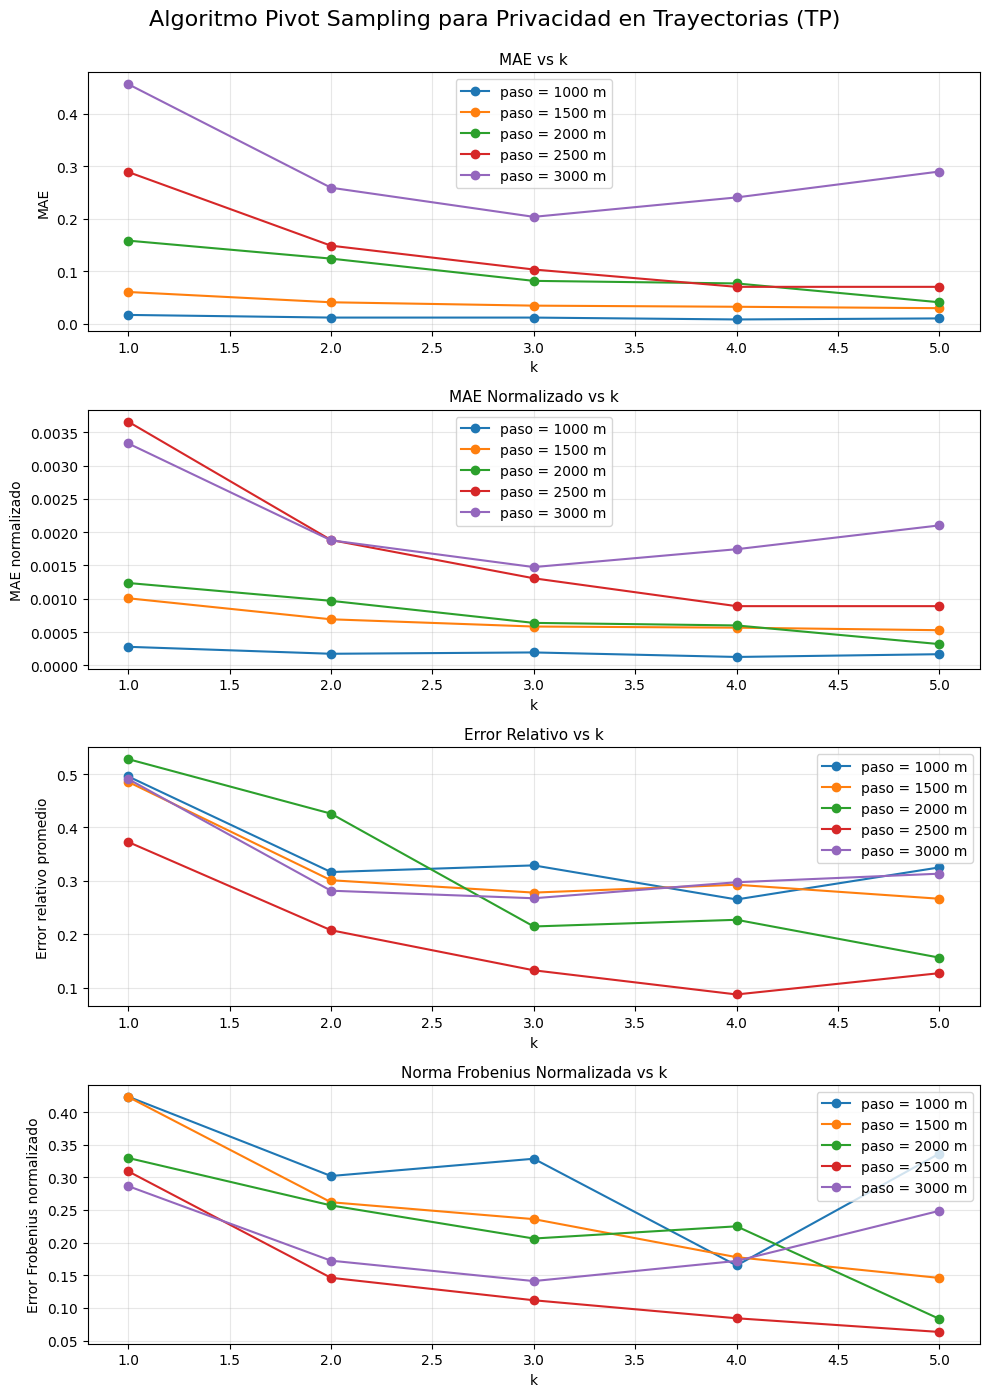

 Tabla HTML guardada en: ../artifacts/pivot/analysis_outputs\tabla_metricas.html


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ================================
# CONFIGURACIÓN
# ================================
carpeta_salida = "../artifacts/pivot/analysis_outputs"

# Buscar todos los pares de archivos originales y perturbados
archivos_original = sorted(glob.glob(os.path.join(carpeta_salida, "OD_original_k*.csv")))
archivos_perturbada = sorted(glob.glob(os.path.join(carpeta_salida, "OD_perturbada_k*.csv")))

# Lista donde guardaremos los resultados de las métricas
resultados = []

# ================================
# 1⃣ CALCULAR MÉTRICAS PARA CADA PAR
# ================================
for orig_file, pert_file in zip(archivos_original, archivos_perturbada):
 # Extraer k y paso_m desde el nombre del archivo
 nombre = os.path.basename(orig_file)
 partes = nombre.replace(".csv", "").split("_")
 k = int(partes[2].replace("k", ""))
 paso_m = int(partes[3].replace("paso", ""))

 # Cargar matrices originales y perturbadas
 original = pd.read_csv(orig_file, header=0).values
 perturbada = pd.read_csv(pert_file, header=0).values

 # Calcular MAE (Error Absoluto Medio)
 mae = np.mean(np.abs(original - perturbada))
 mae_norm = mae / np.max(original) if np.max(original) != 0 else 0

 # Calcular Error Relativo (promedio por celda)
 mask = original != 0 # evitar división por cero
 if np.any(mask):
 error_relativo = np.mean(np.abs((original[mask] - perturbada[mask]) / original[mask]))
 else:
 error_relativo = 0

 # Calcular Norma de Frobenius (diferencia matricial)
 frobenius = np.linalg.norm(original - perturbada)
 frobenius_norm = frobenius / np.linalg.norm(original) if np.linalg.norm(original) != 0 else 0

 # Guardar resultados
 resultados.append({
 "k": k,
 "paso_m": paso_m,
 "MAE": mae,
 "MAE_normalizado": mae_norm,
 "Error_relativo": error_relativo,
 "Frobenius_normalizada": frobenius_norm
 })

# Verificar si hay resultados
if not resultados:
 raise ValueError(" No se encontraron archivos OD_original_k*.csv y OD_perturbada_k*.csv en la carpeta especificada.")

# Convertir los resultados en un DataFrame ordenado
df_resultados = pd.DataFrame(resultados).sort_values(by=["paso_m", "k"])

# Guardar los resultados en CSV
archivo_resultados = os.path.join(carpeta_salida, "metricas_comparacion.csv")
df_resultados.to_csv(archivo_resultados, index=False)
print(f" Métricas guardadas en: {archivo_resultados}")

# ================================
# 2⃣ MOSTRAR TABLA DE VALORES
# ================================
print("\n" + "="*80)
print("TABLA DE VALORES - ALGORITMO PIVOT SAMPLING PARA PRIVACIDAD EN TRAYECTORIAS (TP)")
print("="*80)
print(df_resultados.to_string(index=False))
print("="*80 + "\n")

# ================================
# 3⃣ GRAFICAR LAS MÉTRICAS
# ================================
fig = plt.figure(figsize=(10, 14))
fig.suptitle("Algoritmo Pivot Sampling para Privacidad en Trayectorias (TP)", fontsize=16, y=0.995)

# --- Gráfico 1: MAE ---
plt.subplot(4, 1, 1)
for paso in sorted(df_resultados["paso_m"].unique()):
 datos = df_resultados[df_resultados["paso_m"] == paso]
 plt.plot(datos["k"], datos["MAE"], marker='o', label=f"paso = {paso} m")
plt.title("MAE vs k", fontsize=11)
plt.xlabel("k")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Gráfico 2: MAE Normalizado ---
plt.subplot(4, 1, 2)
for paso in sorted(df_resultados["paso_m"].unique()):
 datos = df_resultados[df_resultados["paso_m"] == paso]
 plt.plot(datos["k"], datos["MAE_normalizado"], marker='o', label=f"paso = {paso} m")
plt.title("MAE Normalizado vs k", fontsize=11)
plt.xlabel("k")
plt.ylabel("MAE normalizado")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Gráfico 3: Error Relativo ---
plt.subplot(4, 1, 3)
for paso in sorted(df_resultados["paso_m"].unique()):
 datos = df_resultados[df_resultados["paso_m"] == paso]
 plt.plot(datos["k"], datos["Error_relativo"], marker='o', label=f"paso = {paso} m")
plt.title("Error Relativo vs k", fontsize=11)
plt.xlabel("k")
plt.ylabel("Error relativo promedio")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Gráfico 4: Norma de Frobenius ---
plt.subplot(4, 1, 4)
for paso in sorted(df_resultados["paso_m"].unique()):
 datos = df_resultados[df_resultados["paso_m"] == paso]
 plt.plot(datos["k"], datos["Frobenius_normalizada"], marker='o', label=f"paso = {paso} m")
plt.title("Norma Frobenius Normalizada vs k", fontsize=11)
plt.xlabel("k")
plt.ylabel("Error Frobenius normalizado")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida, "graficas_metricas.png"), dpi=300, bbox_inches='tight')
print(f" Gráficas guardadas en: {os.path.join(carpeta_salida, 'graficas_metricas.png')}")
plt.show()

# ================================
# 4⃣ CREAR TABLA FORMATEADA EN HTML (OPCIONAL)
# ================================
tabla_html = df_resultados.to_html(index=False, float_format=lambda x: f'{x:.6f}')
archivo_tabla = os.path.join(carpeta_salida, "tabla_metricas.html")
with open(archivo_tabla, 'w') as f:
 f.write(f"<h2>Algoritmo Pivot Sampling para Privacidad en Trayectorias (TP) - Tabla de Métricas</h2>\n{tabla_html}")
print(f" Tabla HTML guardada en: {archivo_tabla}")
